# Сравнение двух условных DCGAN на Fashion MNIST

Цель проекта - не только обучить две модели семейства DCGAN, но и проверить, насколько устойчиво они генерируют изображения одежды по заданному классу.

В эксперименте сравниваются две архитектуры генератора при одинаковом дискриминаторе, одинаковых данных, одинаковом цикле обучения и одинаковом наборе метрик:

1. **Базовая условная DCGAN** - компактный генератор с транспонированными свертками. Он ближе к классической идее DCGAN и служит сильной базовой моделью.
2. **Усиленная условная DCGAN** - более глубокий генератор с масштабированием изображения и сверточной доработкой. Он проверяет гипотезу о том, что более сложный генератор может дать более гладкие и устойчивые изображения.

Ключевой исследовательский вопрос: **дает ли усложнение генератора выигрыш в качестве генерации Fashion MNIST или компактная DCGAN оказывается достаточной для изображений 28 x 28?**

Для честного сравнения используется единая схема обучения:

- один и тот же условный проекционный дискриминатор;
- hinge-функция потерь для GAN;
- EMA-версия генератора для финальной оценки;
- одинаковые параметры оптимизации;
- одинаковые выборки для оценки качества;
- независимый оценочный классификатор, который не участвует в обучении GAN.

Оценка качества строится по нескольким признакам. Одна метрика недостаточна для GAN, поэтому в исследовании используются FID-подобная оценка, покрытие классов, соответствие заданной метке, разнообразие признаков, показатели резких пиксельных перепадов, визуальные сетки и проверка ближайших соседей.


## 1. Импорт библиотек



In [ ]:
# Базовые библиотеки Python.
import json
import math
import os
import random
import subprocess
import time
import warnings
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

# Численные расчеты и таблицы.
import numpy as np
import pandas as pd

# Визуализация.
import matplotlib.pyplot as plt

# Отображение таблиц в ноутбуке.
from IPython.display import display

# TensorFlow и Keras.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# sqrtm нужен для FID-подобной оценки.
from scipy import linalg

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Конфигурация проекта

В этом блоке задается единая конфигурация эксперимента. Все ключевые параметры собраны в `ExperimentConfig`: размер изображения, число классов, размер скрытого вектора, параметры классификатора, параметры GAN, частота оценки, настройки EMA и ограничения для ранней остановки.

Отдельно описаны профили для разных вычислительных устройств. Такой подход позволяет запускать один и тот же ноутбук на T4, L4 и A100 без ручной переписки кода. Профиль выбирает размер пакета, число шагов на эпоху и режим смешанной точности.

Исследовательская причина такого решения - контролируемость. Если параметр влияет на скорость, устойчивость или качество, он должен находиться в конфигурации, а не быть спрятан в середине функции.


In [ ]:
@dataclass(frozen=True)
class ExperimentConfig:
    """Хранит параметры полного эксперимента."""

    # Общие параметры.
    seed: int = 42
    num_classes: int = 10
    image_size: int = 28
    channels: int = 1
    latent_dim: int = 128

    # Параметры классификатора, который используется только для оценки качества.
    classifier_epochs: int = 25
    classifier_batch_size: int = 512
    classifier_learning_rate: float = 1e-3

    # Параметры обучения GAN.
    gan_epochs: int = 180
    steps_per_epoch: int = 220
    batch_size: int = 512
    generator_learning_rate: float = 2e-4
    discriminator_learning_rate: float = 2e-4
    adam_beta_1: float = 0.0
    adam_beta_2: float = 0.9
    global_clipnorm: float = 5.0

    # Условное обучение.
    wrong_label_weight: float = 0.25
    generator_total_variation_weight: float = 0.02

    # Сглаживание весов генератора для финальной генерации.
    ema_decay: float = 0.999

    # Небольшой шум и аугментация для входов дискриминатора.
    instance_noise_initial: float = 0.08
    instance_noise_decay_epochs: int = 80
    augmentation_probability: float = 0.35
    max_translation: int = 2

    # Периодичность оценки качества.
    evaluation_every: int = 5
    eval_samples: int = 3000
    final_eval_samples: int = 6000
    grid_samples_per_class: int = 10

    # Обратные вызовы пользовательского цикла обучения.
    plateau_patience: int = 5
    early_stop_patience: int = 18
    lr_reduce_factor: float = 0.65
    min_learning_rate: float = 3e-6
    quality_min_delta: float = 0.002

    # Производительность.
    mixed_precision: bool = True


@dataclass(frozen=True)
class HardwareProfile:
    """Описывает настройки под конкретную видеокарту."""

    batch_size: int
    steps_per_epoch: int
    gan_epochs: int
    eval_samples: int
    final_eval_samples: int
    mixed_precision: bool


HARDWARE_PROFILES: Dict[str, HardwareProfile] = {
    "T4": HardwareProfile(
        batch_size=384,
        steps_per_epoch=200,
        gan_epochs=180,
        eval_samples=2500,
        final_eval_samples=5000,
        mixed_precision=True,
    ),
    "L4": HardwareProfile(
        batch_size=512,
        steps_per_epoch=220,
        gan_epochs=180,
        eval_samples=3000,
        final_eval_samples=6000,
        mixed_precision=True,
    ),
    "A100": HardwareProfile(
        batch_size=768,
        steps_per_epoch=260,
        gan_epochs=200,
        eval_samples=5000,
        final_eval_samples=10000,
        mixed_precision=True,
    ),
    "CPU": HardwareProfile(
        batch_size=128,
        steps_per_epoch=40,
        gan_epochs=20,
        eval_samples=1000,
        final_eval_samples=2000,
        mixed_precision=False,
    ),
}

PROJECT_DIR = Path("/content/dcgan_fashion_mnist_final") if Path("/content").exists() else Path("dcgan_fashion_mnist_final")
IMAGE_DIR = PROJECT_DIR / "images"
MODEL_DIR = PROJECT_DIR / "models"
TABLE_DIR = PROJECT_DIR / "tables"

for directory in [PROJECT_DIR, IMAGE_DIR, MODEL_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


После выполнения создаются базовая конфигурация, словарь аппаратных профилей и каталоги для артефактов. Важный исследовательский плюс - все параметры обучения заданы централизованно.

В этой версии основные параметры GAN не разбросаны по коду. Это снижает риск случайных расхождений между двумя моделями и делает эксперимент воспроизводимым.


## 3. Определение аппаратного профиля

Блок определяет доступную видеокарту через `nvidia-smi`, выбирает профиль обучения и печатает итоговую конфигурацию. Для Colab это особенно важно, потому что T4, L4 и A100 имеют разные объемы видеопамяти и разную производительность.

В исследовании используется фиксированная логика выбора профиля. Если обнаружена L4, берется профиль с большим размером пакета и увеличенным числом шагов на эпоху. Если видеокарта не обнаружена, выбирается минимальный CPU-профиль только для проверки корректности кода.

Результат этого блока определяет вычислительный режим всего эксперимента: скорость обучения, потребление памяти, число обновлений весов и устойчивость загрузки GPU.


In [ ]:
def query_gpu_name() -> str:
    """Возвращает название первой доступной видеокарты через nvidia-smi."""
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True,
            capture_output=True,
            text=True,
        )
        names = [line.strip() for line in result.stdout.splitlines() if line.strip()]
        return names[0] if names else "CPU"
    except Exception:
        return "CPU"


def select_profile_name(gpu_name: str) -> str:
    """Выбирает имя профиля по названию видеокарты."""
    normalized_name = gpu_name.upper()
    lookup = {
        "A100": "A100",
        "L4": "L4",
        "T4": "T4",
    }
    for marker, profile_name in lookup.items():
        if marker in normalized_name:
            return profile_name
    return "CPU" if not tf.config.list_physical_devices("GPU") else "L4"


def make_config_for_hardware() -> Tuple[ExperimentConfig, str, str]:
    """Создает итоговую конфигурацию с учетом текущей видеокарты."""
    gpu_name = query_gpu_name()
    profile_name = select_profile_name(gpu_name)
    profile = HARDWARE_PROFILES[profile_name]

    base_config = ExperimentConfig()
    config = replace(
        base_config,
        batch_size=profile.batch_size,
        steps_per_epoch=profile.steps_per_epoch,
        gan_epochs=profile.gan_epochs,
        eval_samples=profile.eval_samples,
        final_eval_samples=profile.final_eval_samples,
        mixed_precision=profile.mixed_precision,
    )
    return config, gpu_name, profile_name


CONFIG, GPU_NAME, PROFILE_NAME = make_config_for_hardware()

print(f"Видеокарта: {GPU_NAME}")
print(f"Выбранный профиль: {PROFILE_NAME}")
print(json.dumps(asdict(CONFIG), ensure_ascii=False, indent=2))


Видеокарта: NVIDIA L4
Выбранный профиль: L4
{
  "seed": 42,
  "num_classes": 10,
  "image_size": 28,
  "channels": 1,
  "latent_dim": 128,
  "classifier_epochs": 25,
  "classifier_batch_size": 512,
  "classifier_learning_rate": 0.001,
  "gan_epochs": 180,
  "steps_per_epoch": 220,
  "batch_size": 512,
  "generator_learning_rate": 0.0002,
  "discriminator_learning_rate": 0.0002,
  "adam_beta_1": 0.0,
  "adam_beta_2": 0.9,
  "global_clipnorm": 5.0,
  "wrong_label_weight": 0.25,
  "generator_total_variation_weight": 0.02,
  "ema_decay": 0.999,
  "instance_noise_initial": 0.08,
  "instance_noise_decay_epochs": 80,
  "augmentation_probability": 0.35,
  "max_translation": 2,
  "evaluation_every": 5,
  "eval_samples": 3000,
  "final_eval_samples": 6000,
  "grid_samples_per_class": 10,
  "plateau_patience": 5,
  "early_stop_patience": 18,
  "lr_reduce_factor": 0.65,
  "min_learning_rate": 3e-06,
  "quality_min_delta": 0.002,
  "mixed_precision": true
}


В контрольном запуске была обнаружена видеокарта **NVIDIA L4**, поэтому выбран профиль L4. Итоговая конфигурация использует `batch_size = 512`, `steps_per_epoch = 220`, `gan_epochs = 180` и `mixed_precision = True`.

Такая настройка дает достаточно много обновлений весов для качественного обучения и хорошо подходит для GPU с 24 ГБ видеопамяти. Если ноутбук запускается на T4 или A100, точные параметры будут выбраны автоматически по другому профилю.

Важно: профиль влияет на скорость и число обновлений, но не меняет методологию сравнения. Обе GAN-модели внутри одного запуска обучаются в одинаковых условиях.


## 4. Настройка воспроизводимости и режима вычислений

Этот блок фиксирует зерна случайности для Python, NumPy и TensorFlow, а также включает режим `mixed_float16`, если он разрешен выбранным профилем.

Для GAN полная битовая воспроизводимость не гарантируется из-за стохастического обучения и особенностей GPU, но фиксация random.seed снижает разброс между запусками. Это помогает отличать реальные архитектурные эффекты от случайных колебаний.

Смешанная точность ускоряет обучение на современных GPU и снижает потребление видеопамяти. При этом в ноутбуке сохраняется контроль численной устойчивости: перед долгим обучением проверяется один шаг обновления, а в процессе обучения отслеживаются градиенты и конечность значений.


In [ ]:
def configure_tensorflow(config: ExperimentConfig) -> None:
    """Настраивает TensorFlow перед созданием моделей."""
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

    # Единый random.seed делает повторные запуски более сопоставимыми.
    random.seed(config.seed)
    np.random.seed(config.seed)
    tf.keras.utils.set_random_seed(config.seed)

    # Memory growth не заставляет TensorFlow занимать всю память видеокарты сразу.
    for gpu in tf.config.list_physical_devices("GPU"):
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            # Такое возможно, если GPU уже был инициализирован до этой ячейки.
            pass

    # Смешанная точность ускоряет обучение на T4, L4 и A100.
    if config.mixed_precision and tf.config.list_physical_devices("GPU"):
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
    else:
        tf.keras.mixed_precision.set_global_policy("float32")


configure_tensorflow(CONFIG)
print(f"Политика вычислений Keras: {tf.keras.mixed_precision.global_policy()}")


Политика вычислений Keras: <DTypePolicy "mixed_float16">


В контрольном запуске политика вычислений Keras установлена как `mixed_float16`. Это ожидаемо для L4 и означает, что часть операций будет выполняться в половинной точности для ускорения.

Для GAN смешанная точность требует аккуратной диагностики. Поэтому дальше в ноутбуке есть проверка одного шага обучения и отдельный анализ градиентов. В текущем выполненном запуске эти проверки показали устойчивое обучение.


## 5. Служебная диагностика GPU

Здесь определяется функция для быстрой проверки состояния видеокарты. Она выводит название GPU, занятую память, полный объем памяти, загрузку и температуру.

Эта диагностика не является метрикой качества модели. Ее задача - убедиться, что Colab действительно видит видеокарту и что процесс обучения может использовать GPU. Низкая занятость памяти не означает простой. Fashion MNIST имеет размер 28 x 28, поэтому задача сама по себе не требует большого объема видеопамяти.

Блок полезен перед и после тяжелых участков ноутбука. По нему можно понять, какой ресурс доступен и нет ли очевидных проблем с окружением.


In [ ]:
def show_gpu_status() -> None:
    """Печатает краткую сводку nvidia-smi без использования shell-команд."""
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.used,memory.total,utilization.gpu,temperature.gpu",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        print("name, memory.used MiB, memory.total MiB, utilization.gpu %, temperature.gpu C")
        print(result.stdout.strip())
    except Exception as error:
        print(f"GPU-диагностика недоступна: {error}")


show_gpu_status()


name, memory.used MiB, memory.total MiB, utilization.gpu %, temperature.gpu C
NVIDIA L4, 3, 23034, 0, 40


В момент проверки GPU почти не был занят. Вывод показал `NVIDIA L4`, около 3 MiB занятой памяти и 0 процентов загрузки. Это нормально до начала обучения, потому что модели еще не начали активно выполнять вычисления.

Эта ячейка подтверждает, что видеокарта доступна и что окружение Colab видит ее через `nvidia-smi`.


## 6. Загрузка Fashion MNIST

В этом блоке загружается датасет Fashion MNIST из набора TensorFlow. Датасет содержит 10 классов одежды и обуви, изображения в оттенках серого размером 28 x 28 и стандартное разделение на обучающую и проверочную выборки.

Исследовательски этот набор удобен для сравнения GAN. Классы достаточно различимы по силуэту, но часть категорий похожа между собой. Например, `футболка или топ`, `рубашка`, `пуловер` и `пальто` часто имеют близкие контуры. Поэтому простое соответствие классу не всегда означает идеальное визуальное качество.

На этом этапе данные еще не нормализуются. Сначала важно проверить исходные размеры, количество классов и корректность загрузки.


In [ ]:
CLASS_NAMES = np.array(
    [
        "футболка или топ",
        "брюки",
        "пуловер",
        "платье",
        "пальто",
        "сандалия",
        "рубашка",
        "кроссовок",
        "сумка",
        "ботинок",
    ],
    dtype=object,
)

(train_images_raw, train_labels), (test_images_raw, test_labels) = keras.datasets.fashion_mnist.load_data()
train_labels = train_labels.astype("int32")
test_labels = test_labels.astype("int32")

print(f"Обучающие изображения: {train_images_raw.shape}")
print(f"Проверочные изображения: {test_images_raw.shape}")
print(f"Количество классов: {len(CLASS_NAMES)}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Обучающие изображения: (60000, 28, 28)
Проверочные изображения: (10000, 28, 28)
Количество классов: 10


Датасет загрузился корректно: обучающая выборка имеет форму `(60000, 28, 28)`, проверочная выборка - `(10000, 28, 28)`, количество классов - 10.

Это стандартная структура Fashion MNIST. Размеры соответствуют ожиданиям, поэтому дальше можно выполнять EDA, нормализацию и обучение моделей.


## 7. Разведочный анализ - баланс классов

Этот блок проверяет, равномерно ли представлены классы в обучающей и проверочной выборках. Баланс классов важен для условной генерации: если один класс встречается намного реже, модель может хуже научиться создавать его изображения.

Fashion MNIST устроен сбалансированно, поэтому ожидается одинаковое количество объектов каждого класса. Это снижает риск того, что выпадение класса будет вызвано самим датасетом.

График баланса является первым контрольным графиком исследования. Он отвечает на вопрос: можно ли сравнивать качество генерации по всем 10 классам без дополнительных весов классов или ресэмплинга.


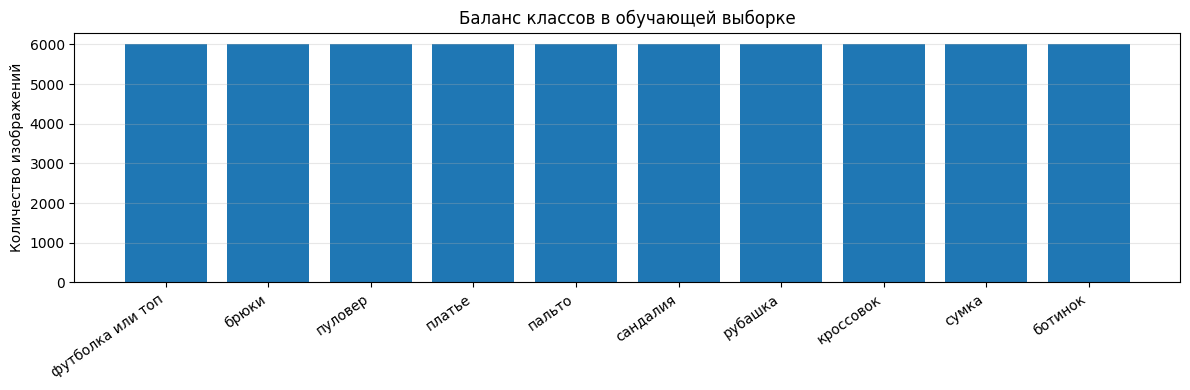

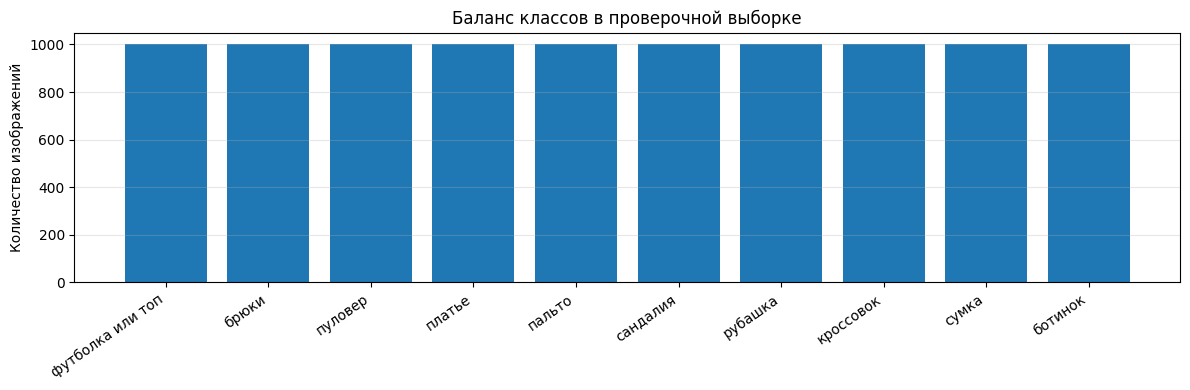

In [ ]:
def plot_class_balance(labels: np.ndarray, title: str) -> None:
    """Строит диаграмму количества объектов каждого класса."""
    counts = np.bincount(labels, minlength=len(CLASS_NAMES))
    positions = np.arange(len(CLASS_NAMES))

    plt.figure(figsize=(12, 4))
    plt.bar(positions, counts)
    plt.xticks(positions, CLASS_NAMES, rotation=35, ha="right")
    plt.ylabel("Количество изображений")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_class_balance(train_labels, "Баланс классов в обучающей выборке")
plot_class_balance(test_labels, "Баланс классов в проверочной выборке")


Графики баланса показывают равномерное распределение классов. Для Fashion MNIST в обучающей выборке по 6000 изображений каждого класса, а в проверочной - по 1000.

Это важное наблюдение: если какая-то категория будет плохо генерироваться, причину нужно искать в архитектуре, тренировочном процессе или близости классов, а не в дисбалансе исходных данных.


## 8. Разведочный анализ - примеры изображений

Блок показывает реальные изображения из каждого класса. Эта визуализация нужна до обучения GAN, потому что она задает зрительный эталон качества.

По реальным примерам можно оценить, какие признаки модель должна научиться воспроизводить: общий силуэт, ширину объекта, положение в кадре, характерные детали и уровень шума. Для Fashion MNIST важнее правильная форма и расположение объекта, чем мелкие текстуры.

Эта ячейка также помогает понять, какие классы потенциально будут путаться. Верхняя одежда и рубашки визуально близки, а обувные классы отличаются сильнее.


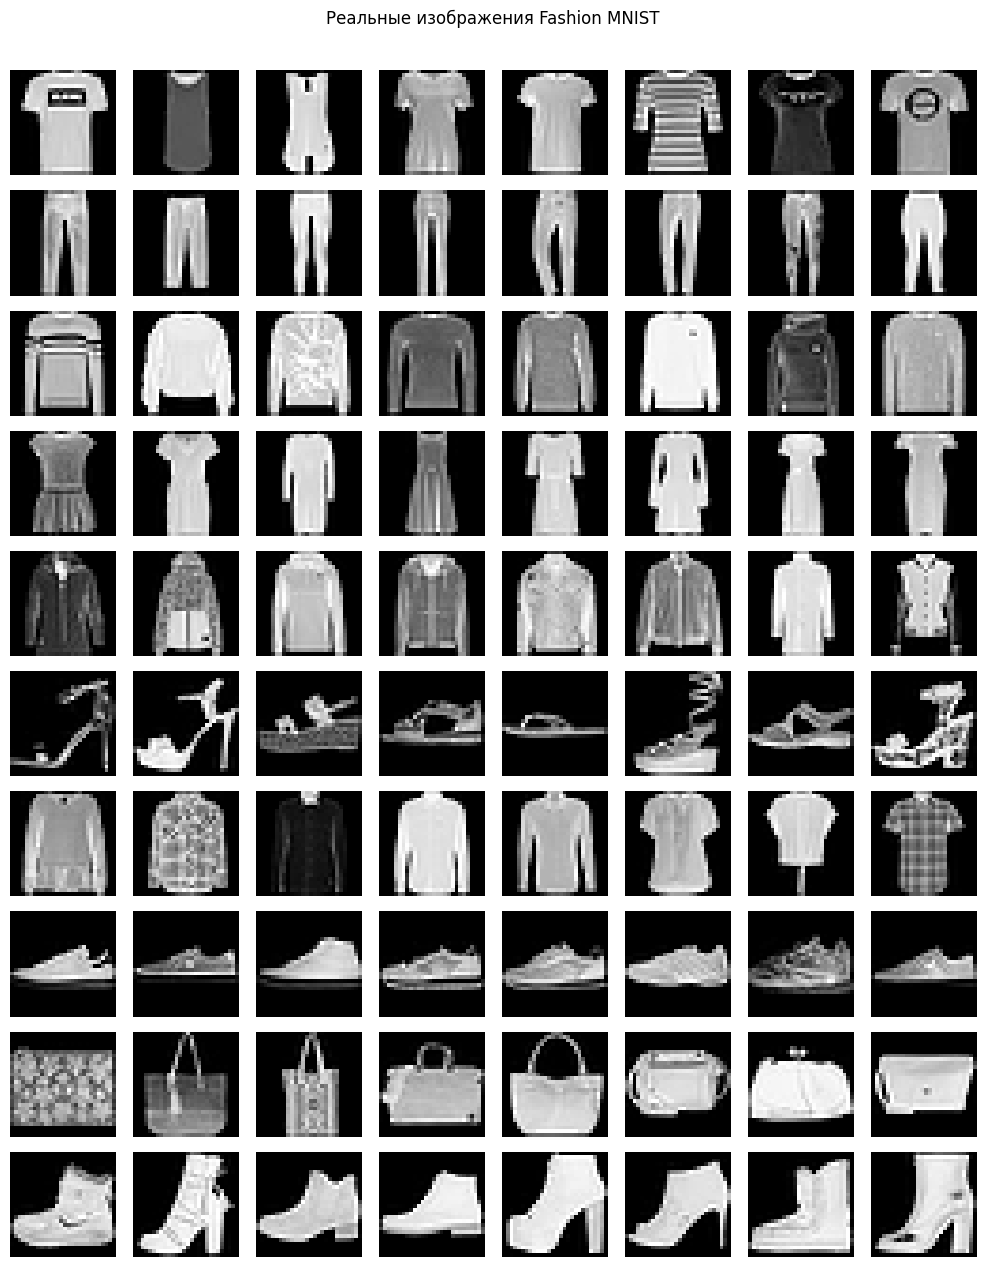

In [ ]:
def plot_examples_by_class(images: np.ndarray, labels: np.ndarray, samples_per_class: int = 8) -> None:
    """Показывает несколько реальных примеров для каждого класса."""
    rows = len(CLASS_NAMES)
    cols = samples_per_class
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.25))

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_indices = np.where(labels == class_id)[0][:samples_per_class]
        for col, image_index in enumerate(class_indices):
            ax = axes[class_id, col]
            ax.imshow(images[image_index], cmap="gray", vmin=0, vmax=255)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=55, va="center")

    plt.suptitle("Реальные изображения Fashion MNIST", y=1.01)
    plt.tight_layout()
    plt.show()


plot_examples_by_class(train_images_raw, train_labels, samples_per_class=8)


Сетка реальных изображений показывает, что данные хорошо выровнены. Объекты находятся в центре кадра, фон почти черный, а основные различия между классами задаются силуэтом.

Классы обуви и сумок визуально отделяются легче. Верхняя одежда сложнее: `футболка или топ`, `рубашка`, `пуловер` и `пальто` имеют похожую форму, поэтому ошибки между ними ожидаемы даже у хорошей модели.

Эта визуальная база нужна для финального сравнения. Сгенерированные изображения должны быть похожи на эти реальные образцы не пиксельно, а по силуэту и структуре класса.


## 9. Разведочный анализ - яркость и средние изображения

Здесь анализируется распределение яркости пикселей и строятся средние изображения по каждому классу. Распределение яркости показывает, насколько разрежены изображения: большая часть фона почти черная, а объект занимает центральную область.

Средние изображения позволяют увидеть типичный силуэт класса. Если средний образ четкий, значит объекты класса хорошо выровнены в кадре. Это благоприятно для DCGAN. Модели проще изучать распределение, когда объекты имеют стабильное положение.

Эти графики также объясняют, почему для Fashion MNIST хорошо работают простые сверточные генераторы. Размер изображения малый, фон однородный, а классы различаются в основном контуром.


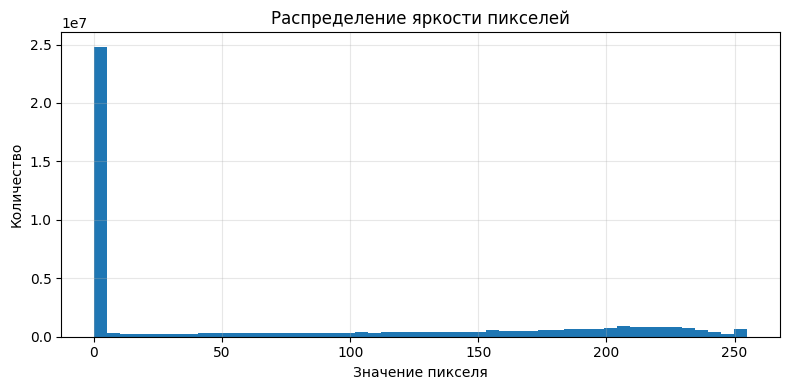

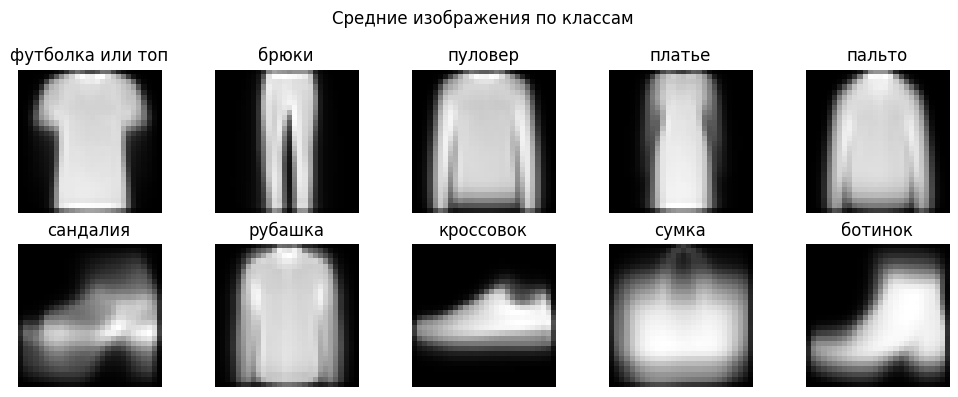

In [ ]:
def plot_pixel_statistics(images: np.ndarray) -> None:
    """Показывает распределение значений пикселей."""
    plt.figure(figsize=(8, 4))
    plt.hist(images.reshape(-1), bins=50)
    plt.xlabel("Значение пикселя")
    plt.ylabel("Количество")
    plt.title("Распределение яркости пикселей")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_average_images(images: np.ndarray, labels: np.ndarray) -> None:
    """Показывает средний силуэт каждого класса."""
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.ravel()

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_images = images[labels == class_id]
        mean_image = class_images.mean(axis=0)
        axes[class_id].imshow(mean_image, cmap="gray")
        axes[class_id].set_title(class_name)
        axes[class_id].axis("off")

    plt.suptitle("Средние изображения по классам")
    plt.tight_layout()
    plt.show()


plot_pixel_statistics(train_images_raw)
plot_average_images(train_images_raw, train_labels)


Гистограмма яркости подтверждает разреженность изображений. Большая часть пикселей относится к темному фону, а информативные пиксели сосредоточены в объекте. Это типично для Fashion MNIST.

Средние изображения по классам показывают стабильные силуэты. Например, брюки имеют вытянутую вертикальную форму, сумка - компактный корпус с ручкой, обувь - горизонтальный силуэт. Такая структура облегчает условную генерацию.

Для GAN это означает, что модель должна научиться прежде всего геометрии класса. Слишком сильные шумовые текстуры будут заметны по полной вариации и визуальным сеткам.


## 10. Нормализация данных

GAN и оценочный классификатор используют разные диапазоны входных данных. Для генератора изображения переводятся в диапазон `[-1, 1]`, потому что последний слой генератора использует `tanh`. Для классификатора изображения переводятся в диапазон `[0, 1]`, что естественно для сверточной классификации.

Разделение нормализации снижает риск скрытых ошибок. Генератор и дискриминатор работают в одном масштабе, а оценочный классификатор получает данные в привычном диапазоне.

Этот блок также добавляет канал изображения, превращая форму `28 x 28` в `28 x 28 x 1`. Сверточные слои TensorFlow ожидают явную размерность канала.


In [ ]:
def normalize_for_gan(images: np.ndarray) -> np.ndarray:
    """Преобразует изображения из [0, 255] в [-1, 1]."""
    images = images.astype("float32")
    images = (images - 127.5) / 127.5
    return images[..., np.newaxis]


def normalize_for_classifier(images: np.ndarray) -> np.ndarray:
    """Преобразует изображения из [0, 255] в [0, 1]."""
    images = images.astype("float32") / 255.0
    return images[..., np.newaxis]


train_images_gan = normalize_for_gan(train_images_raw)
test_images_gan = normalize_for_gan(test_images_raw)
train_images_classifier = normalize_for_classifier(train_images_raw)
test_images_classifier = normalize_for_classifier(test_images_raw)

print(f"Диапазон GAN: {train_images_gan.min():.1f} .. {train_images_gan.max():.1f}")
print(f"Диапазон классификатора: {train_images_classifier.min():.1f} .. {train_images_classifier.max():.1f}")


Диапазон GAN: -1.0 .. 1.0
Диапазон классификатора: 0.0 .. 1.0


Диапазоны преобразованы корректно: для GAN получен интервал `-1.0 .. 1.0`, для классификатора - `0.0 .. 1.0`.

Это критический контроль. Если бы генератор и дискриминатор получили разные масштабы, обучение могло бы стать нестабильным. Если бы классификатор получил изображения в диапазоне `[-1, 1]`, его проверочная точность и оценочные метрики стали бы ненадежными.


## 11. Быстрый конвейер данных

В этом блоке создаются `tf.data`-конвейеры для классификатора и GAN. Используются кеширование, перемешивание, повторение, фиксированный размер пакета и предварительная подача данных.

Цель - минимизировать простой GPU. Если данные подаются медленно, видеокарта ждет CPU и обучение замедляется. Для Fashion MNIST данные маленькие, поэтому кеширование особенно эффективно.

Для GAN используется `drop_remainder=True`, чтобы все пакеты имели одинаковую форму. Это уменьшает накладные расходы трассировки графа TensorFlow и стабилизирует пользовательский цикл обучения.


In [ ]:
def apply_fast_dataset_options(dataset: tf.data.Dataset) -> tf.data.Dataset:
    """Применяет безопасные настройки производительности tf.data."""
    options = tf.data.Options()
    options.experimental_deterministic = False
    return dataset.with_options(options)


def build_classifier_dataset(
    images: np.ndarray,
    labels: np.ndarray,
    batch_size: int,
    training: bool,
) -> tf.data.Dataset:
    """Создает датасет для обучения или проверки классификатора."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels.astype("int32")))
    dataset = dataset.cache()

    if training:
        dataset = dataset.shuffle(len(images), reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return apply_fast_dataset_options(dataset)


def build_gan_dataset(images: np.ndarray, labels: np.ndarray, config: ExperimentConfig) -> tf.data.Dataset:
    """Создает бесконечный датасет для GAN с фиксированным размером пакета."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels.astype("int32")))
    dataset = dataset.cache()
    dataset = dataset.shuffle(len(images), reshuffle_each_iteration=True)
    dataset = dataset.repeat()
    dataset = dataset.batch(config.batch_size, drop_remainder=True)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return apply_fast_dataset_options(dataset)


classifier_train_ds = build_classifier_dataset(
    train_images_classifier,
    train_labels,
    CONFIG.classifier_batch_size,
    training=True,
)
classifier_test_ds = build_classifier_dataset(
    test_images_classifier,
    test_labels,
    CONFIG.classifier_batch_size,
    training=False,
)
gan_train_ds = build_gan_dataset(train_images_gan, train_labels, CONFIG)

print("Конвейеры данных подготовлены")


Конвейеры данных подготовлены


Сообщение `Конвейеры данных подготовлены` означает, что наборы данных для классификатора и GAN созданы без ошибок.

Для GPU-обучения важны три особенности этого блока. Кеширование снижает нагрузку на CPU, предварительная подача уменьшает ожидание данных, а фиксированный размер пакета стабилизирует граф TensorFlow. В результате обучение на L4 идет с устойчивым временем эпохи.


## 12. Оценочный классификатор

Этот блок создает сверточный классификатор Fashion MNIST. Классификатор не участвует в функции потерь GAN. Он используется только как независимый измеритель качества после генерации.

Классификатор нужен для нескольких задач: оценки соответствия заданной метке, построения распределения предсказанных классов, вычисления признакового пространства для FID-подобной оценки и диагностики покрытия классов.

Такая схема снижает риск подгонки генератора под классификатор. Генератор получает сигнал только от дискриминатора, а классификатор остается внешним измерителем.


In [ ]:
def build_quality_classifier(config: ExperimentConfig) -> keras.Model:
    """Создает CNN-классификатор Fashion MNIST и слой признаков для метрик."""
    inputs = keras.Input(
        shape=(config.image_size, config.image_size, config.channels),
        name="image",
    )

    # Первый блок извлекает простые контуры и локальные структуры.
    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

    # Второй блок отвечает за более крупные части силуэта.
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Финальный блок формирует компактный вектор признаков.
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    features = layers.Dense(128, activation="relu", dtype="float32", name="features")(x)
    outputs = layers.Dense(config.num_classes, activation="softmax", dtype="float32", name="probabilities")(features)

    model = keras.Model(inputs, outputs, name="quality_classifier")
    return model


quality_classifier = build_quality_classifier(CONFIG)
quality_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG.classifier_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

quality_classifier.summary()


Model: "quality_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 128)            │        16,51

 Total params: 157,610 (615.66 KB)

 Trainable params: 156,970 (613.16 KB)

 Non-trainable params: 640 (2.50 KB)

В выводе отображается структура классификатора. Модель достаточно компактная для Fashion MNIST, но содержит несколько сверточных блоков, нормализацию и слой признаков, который позже используется для оценки FID-подобной метрики.

Классификатор намеренно не является чрезмерно сложным. Его задача - надежно оценивать классы и признаки, а не становиться отдельным главным объектом исследования.


## 13. Обучение оценочного классификатора

Здесь обучается классификатор, который позже будет использоваться для оценки генераторов. В обучении применяются стандартные колбэки: сохранение лучшей модели, снижение скорости обучения при плато и ранняя остановка.

Качество классификатора важно для анализа, но не должно становиться целью всего проекта. Если классификатор слишком слабый, метрики соответствия классу будут ненадежны. Если классификатор сильный, но используется в функции потерь генератора, появляется риск генерации паттернов, удобных классификатору, но плохих визуально. В этой работе второй риск устранен: классификатор только оценивает.

После обучения загружается лучшая сохраненная версия классификатора по проверочной точности.


In [ ]:
classifier_checkpoint_path = MODEL_DIR / "quality_classifier.keras"

classifier_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(classifier_checkpoint_path),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

classifier_history_object = quality_classifier.fit(
    classifier_train_ds,
    validation_data=classifier_test_ds,
    epochs=CONFIG.classifier_epochs,
    callbacks=classifier_callbacks,
    verbose=1,
)

classifier_history = pd.DataFrame(classifier_history_object.history)
classifier_history.to_csv(TABLE_DIR / "classifier_history.csv", index=False)

print("Лучшая проверочная точность:", f"{classifier_history['val_accuracy'].max():.4f}")


Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5921 - loss: 1.1798
Epoch 1: val_accuracy improved from None to 0.10000, saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras

Epoch 1: finished saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 219ms/step - accuracy: 0.7239 - loss: 0.7877 - val_accuracy: 0.1000 - val_loss: 5.5241 - learning_rate: 0.0010
Epoch 2/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8468 - loss: 0.4233
Epoch 2: val_accuracy improved from 0.10000 to 0.18990, saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras

Epoch 2: finished saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8573 - loss: 0.3945 - val_accuracy: 0.1899 - val_loss: 5.0547 - learning_rate: 0.0010
Epoch 3/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accurac

В контрольном запуске классификатор достиг лучшей проверочной точности **0.9321** на 25-й эпохе. Это хороший результат для использования модели как внешнего оценщика качества.

Начало обучения показывает типичную динамику. Проверочная точность сначала низкая, затем быстро растет после стабилизации нормализации и признаков. После 9-й эпохи качество уже превышает 0.90, а дальнейшие эпохи дают небольшой, но полезный прирост.

Классификатор достаточно надежен для оценки покрытия классов и соответствия меткам. При этом его результаты нужно читать с учетом близости некоторых классов верхней одежды.


## 14. Графики обучения классификатора

Этот блок строит графики точности и ошибки классификатора на обучающей и проверочной выборках.

Графики нужны для проверки двух вещей. Во-первых, классификатор должен действительно обучиться и достичь высокой проверочной точности. Во-вторых, между обучением и проверкой не должно быть чрезмерного разрыва, иначе классификатор будет плохо обобщать и станет ненадежным измерителем генерации.

В дальнейшем этот классификатор будет использоваться как часть системы оценки, поэтому его динамика должна быть понятной и проверенной.


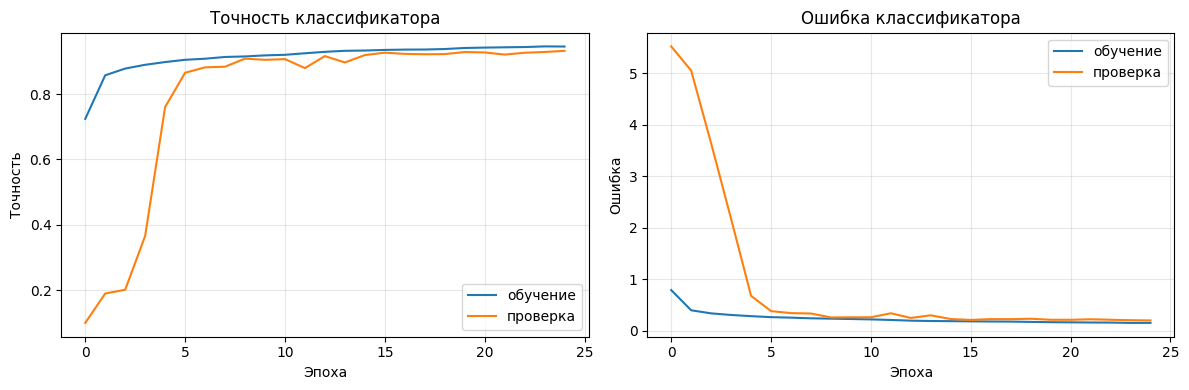

In [ ]:
def plot_classifier_history(history: pd.DataFrame) -> None:
    """Показывает динамику точности и ошибки классификатора."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["accuracy"], label="обучение")
    axes[0].plot(history["val_accuracy"], label="проверка")
    axes[0].set_title("Точность классификатора")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Точность")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["loss"], label="обучение")
    axes[1].plot(history["val_loss"], label="проверка")
    axes[1].set_title("Ошибка классификатора")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Ошибка")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_classifier_history(classifier_history)


График точности показывает, что обучающая точность растет плавно, а проверочная точность после первых эпох быстро выходит на высокий уровень. Лучшее значение в контрольном запуске - **0.9321**.

График функции ошибки показывает снижение ошибки на обучающей и проверочной выборках. В начале проверочная ошибка может быть высокой из-за статистики нормализации и начальной адаптации модели, но затем она быстро стабилизируется.

Критичного переобучения не видно. Проверочная точность остается высокой, а модель сохраняет способность обобщать. Поэтому классификатор можно использовать как оценочный инструмент для GAN.


## 15. Подготовка признаков реальной выборки

В этом блоке из обученного классификатора выделяется промежуточный слой признаков. Эти признаки используются для сравнения реальных и сгенерированных изображений в более информативном пространстве, чем пиксели.

Также вычисляются базовые статистики реальных изображений: средняя полная вариация, доля сильных соседних перепадов и среднее стандартное отклонение признаков. Они нужны для нормировки метрик качества генераторов.

Такой подход делает оценку более устойчивой. Например, если генератор создает шумные изображения, пиксельная яркость может выглядеть правдоподобно, но полная вариация и FID-подобная оценка ухудшатся.


In [ ]:
feature_extractor = keras.Model(
    quality_classifier.input,
    quality_classifier.get_layer("features").output,
    name="quality_feature_extractor",
)


def gan_to_classifier_range(images: np.ndarray) -> np.ndarray:
    """Переводит изображения из [-1, 1] в [0, 1]."""
    images = np.asarray(images, dtype="float32")
    return np.clip((images + 1.0) / 2.0, 0.0, 1.0)


def extract_probabilities_and_features(
    classifier: keras.Model,
    extractor: keras.Model,
    images_01: np.ndarray,
    batch_size: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Вычисляет вероятности классов и признаки для массива изображений."""
    probabilities_batches: List[np.ndarray] = []
    feature_batches: List[np.ndarray] = []

    for start in range(0, len(images_01), batch_size):
        batch = tf.convert_to_tensor(images_01[start : start + batch_size], dtype=tf.float32)
        probabilities = classifier(batch, training=False)
        features = extractor(batch, training=False)
        probabilities_batches.append(probabilities.numpy().astype("float32"))
        feature_batches.append(features.numpy().astype("float32"))

    return np.concatenate(probabilities_batches, axis=0), np.concatenate(feature_batches, axis=0)


def covariance_with_regularization(features: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Вычисляет ковариационную матрицу с малой регуляризацией диагонали."""
    covariance = np.cov(features, rowvar=False)
    covariance = np.atleast_2d(covariance).astype("float64")
    covariance += np.eye(covariance.shape[0], dtype="float64") * eps
    return covariance


def frechet_distance_from_features(real_features: np.ndarray, generated_features: np.ndarray) -> float:
    """Считает FID-подобное расстояние между признаками реальных и искусственных изображений."""
    real_mean = real_features.mean(axis=0).astype("float64")
    generated_mean = generated_features.mean(axis=0).astype("float64")
    real_covariance = covariance_with_regularization(real_features)
    generated_covariance = covariance_with_regularization(generated_features)

    covariance_product_sqrt = linalg.sqrtm(real_covariance @ generated_covariance)
    if np.iscomplexobj(covariance_product_sqrt):
        covariance_product_sqrt = covariance_product_sqrt.real

    if not np.all(np.isfinite(covariance_product_sqrt)):
        offset = np.eye(real_covariance.shape[0], dtype="float64") * 1e-4
        covariance_product_sqrt = linalg.sqrtm((real_covariance + offset) @ (generated_covariance + offset))
        if np.iscomplexobj(covariance_product_sqrt):
            covariance_product_sqrt = covariance_product_sqrt.real

    mean_difference = real_mean - generated_mean
    distance = mean_difference @ mean_difference
    distance += np.trace(real_covariance + generated_covariance - 2.0 * covariance_product_sqrt)
    return float(max(distance, 0.0))


def total_variation_mean(images: np.ndarray) -> float:
    """Оценивает среднюю резкость соседних пикселей."""
    images = np.asarray(images, dtype="float32")
    horizontal = np.abs(images[:, :, 1:, :] - images[:, :, :-1, :]).mean()
    vertical = np.abs(images[:, 1:, :, :] - images[:, :-1, :, :]).mean()
    return float(horizontal + vertical)


def high_contrast_neighbor_share(images: np.ndarray, threshold: float = 0.55) -> float:
    """Считает долю соседних пикселей с очень большим перепадом яркости."""
    images = np.asarray(images, dtype="float32")
    horizontal = np.abs(images[:, :, 1:, :] - images[:, :, :-1, :]) > threshold
    vertical = np.abs(images[:, 1:, :, :] - images[:, :-1, :, :]) > threshold
    return float(np.concatenate([horizontal.reshape(-1), vertical.reshape(-1)]).mean())


real_reference_images = test_images_gan.astype("float32")
real_reference_images_01 = gan_to_classifier_range(real_reference_images)
real_probabilities, real_features = extract_probabilities_and_features(
    quality_classifier,
    feature_extractor,
    real_reference_images_01,
    batch_size=CONFIG.classifier_batch_size,
)

REAL_TV = total_variation_mean(real_reference_images_01)
REAL_HIGH_CONTRAST = high_contrast_neighbor_share(real_reference_images_01)
REAL_FEATURE_STD = float(np.mean(np.std(real_features, axis=0)) + 1e-8)

print(f"Средняя полная вариация реальных изображений: {REAL_TV:.4f}")
print(f"Доля сильных перепадов у реальных изображений: {REAL_HIGH_CONTRAST:.4f}")
print(f"Среднее стандартное отклонение признаков: {REAL_FEATURE_STD:.4f}")


Средняя полная вариация реальных изображений: 0.1560
Доля сильных перепадов у реальных изображений: 0.0359
Среднее стандартное отклонение признаков: 0.7146


В контрольном запуске получены такие базовые значения реальных изображений: средняя полная вариация `0.1560`, доля сильных перепадов `0.0359`, среднее стандартное отклонение признаков `0.7146`.

Эти числа будут использоваться как ориентиры. Если генератор создает слишком шумные изображения, отношение полной вариации или доля сильных перепадов заметно отклонятся от реальных данных.

Фиксация статистик реальной выборки делает итоговые метрики более интерпретируемыми: модель сравнивается не с абстрактным идеалом, а с фактической структурой Fashion MNIST.


## 16. Оценщик качества генератора

Здесь создаются функции, которые превращают набор сгенерированных изображений в численные метрики. Оценщик объединяет несколько сторон качества: близость к реальному распределению, покрытие классов, соответствие заданной метке, разнообразие признаков и уровень пиксельных артефактов.

Отдельный итоговый балл нужен для выбора лучшего EMA-генератора во время обучения. При этом итоговый балл не заменяет подробные метрики. Он является удобным агрегатом, а интерпретация делается по всей таблице.

Метрики построены так, чтобы не поощрять визуально плохую генерацию. Например, слишком резкие соседние перепады и завышенная полная вариация ухудшают оценку даже при хорошем распознавании классов.


In [ ]:
def normalized_entropy(probabilities: np.ndarray) -> float:
    """Считает энтропию распределения, нормированную на диапазон [0, 1]."""
    probabilities = np.asarray(probabilities, dtype="float64")
    probabilities = probabilities[probabilities > 0]
    if len(probabilities) == 0:
        return 0.0
    entropy = -np.sum(probabilities * np.log(probabilities))
    return float(entropy / np.log(CONFIG.num_classes))


def closeness_to_one_score(value: float, eps: float = 1e-8) -> float:
    """Дает 1.0, если value близко к 1.0, и уменьшается при сильном отклонении."""
    value = max(float(value), eps)
    return float(np.exp(-abs(np.log(value))))


def build_balanced_labels(sample_count: int, num_classes: int, seed: Optional[int] = None) -> np.ndarray:
    """Создает почти равномерный набор меток заданной длины."""
    labels = np.arange(sample_count, dtype="int32") % num_classes
    if seed is not None:
        rng = np.random.default_rng(seed)
        rng.shuffle(labels)
    return labels


class QualityEvaluator:
    """Считает метрики качества для условного генератора."""

    def __init__(
        self,
        classifier: keras.Model,
        extractor: keras.Model,
        real_features: np.ndarray,
        config: ExperimentConfig,
    ) -> None:
        self.classifier = classifier
        self.extractor = extractor
        self.real_features = real_features
        self.config = config

        # Для выбора лучшей модели используется фиксированный набор шумов и меток.
        # Это уменьшает случайные скачки качества между эпохами.
        self.reference_sample_count = max(config.eval_samples, config.final_eval_samples)
        rng = np.random.default_rng(config.seed + 2028)
        self.reference_labels = build_balanced_labels(
            self.reference_sample_count,
            config.num_classes,
            seed=config.seed + 2029,
        )
        self.reference_noise = rng.normal(
            size=(self.reference_sample_count, config.latent_dim),
        ).astype("float32")

    def generate_images(
        self,
        generator: keras.Model,
        labels: np.ndarray,
        noise_vectors: np.ndarray,
        batch_size: int,
    ) -> np.ndarray:
        """Генерирует изображения пакетами, чтобы не переполнять память GPU."""
        generated_batches: List[np.ndarray] = []

        for start in range(0, len(labels), batch_size):
            label_batch = labels[start : start + batch_size].astype("int32")
            noise_batch = noise_vectors[start : start + len(label_batch)].astype("float32")
            images = generator(
                [tf.convert_to_tensor(noise_batch), tf.convert_to_tensor(label_batch)],
                training=False,
            )
            generated_batches.append(images.numpy().astype("float32"))

        return np.concatenate(generated_batches, axis=0)

    def evaluate(
        self,
        generator: keras.Model,
        sample_count: Optional[int] = None,
        return_details: bool = False,
    ):
        """Возвращает словарь метрик и, при необходимости, подробности по классам."""
        count = int(sample_count or self.config.eval_samples)
        requested_labels = self.reference_labels[:count]
        noise_vectors = self.reference_noise[:count]
        generated_images = self.generate_images(
            generator,
            requested_labels,
            noise_vectors=noise_vectors,
            batch_size=self.config.batch_size,
        )
        generated_images_01 = gan_to_classifier_range(generated_images)

        probabilities, features = extract_probabilities_and_features(
            self.classifier,
            self.extractor,
            generated_images_01,
            batch_size=self.config.classifier_batch_size,
        )
        predicted_labels = probabilities.argmax(axis=1).astype("int32")
        class_counts = np.bincount(predicted_labels, minlength=self.config.num_classes)
        class_shares = class_counts / max(1, class_counts.sum())

        condition_match_by_class = []
        for class_id in range(self.config.num_classes):
            mask = requested_labels == class_id
            match = float((predicted_labels[mask] == class_id).mean()) if mask.any() else 0.0
            condition_match_by_class.append(match)

        fid_like = frechet_distance_from_features(self.real_features, features)
        feature_diversity_ratio = float(np.mean(np.std(features, axis=0)) / REAL_FEATURE_STD)
        tv_ratio = total_variation_mean(generated_images_01) / max(REAL_TV, 1e-8)
        high_contrast_ratio = high_contrast_neighbor_share(generated_images_01) / max(REAL_HIGH_CONTRAST, 1e-8)

        coverage_entropy = normalized_entropy(class_shares)
        min_class_share = float(class_shares.min())
        missing_class_count = int(np.sum(class_counts == 0))
        label_match_rate = float((predicted_labels == requested_labels).mean())
        min_condition_match = float(np.min(condition_match_by_class))
        mean_confidence = float(probabilities.max(axis=1).mean())

        # Нормированные подоценки. Они нужны для одного итогового показателя качества.
        fid_score = 1.0 / (1.0 + fid_like / 15.0)
        min_share_score = min(1.0, min_class_share / (0.5 / self.config.num_classes))
        diversity_score = closeness_to_one_score(feature_diversity_ratio)
        tv_score = closeness_to_one_score(tv_ratio)
        contrast_score = closeness_to_one_score(high_contrast_ratio)
        realism_score = 0.55 * tv_score + 0.45 * contrast_score

        quality_score = (
            0.35 * fid_score
            + 0.15 * coverage_entropy
            + 0.15 * label_match_rate
            + 0.10 * min_share_score
            + 0.10 * diversity_score
            + 0.15 * realism_score
        )

        metrics = {
            "fid_like": float(fid_like),
            "coverage_entropy": float(coverage_entropy),
            "label_match_rate": float(label_match_rate),
            "min_class_share": float(min_class_share),
            "missing_class_count": float(missing_class_count),
            "min_condition_match": float(min_condition_match),
            "feature_diversity_ratio": float(feature_diversity_ratio),
            "tv_ratio": float(tv_ratio),
            "high_contrast_ratio": float(high_contrast_ratio),
            "mean_confidence": float(mean_confidence),
            "quality_score": float(quality_score),
        }

        if not return_details:
            return metrics

        details = {
            "requested_labels": requested_labels,
            "predicted_labels": predicted_labels,
            "probabilities": probabilities,
            "features": features,
            "images": generated_images,
            "class_shares": class_shares,
            "condition_match_by_class": np.array(condition_match_by_class, dtype="float32"),
        }
        return metrics, details


quality_evaluator = QualityEvaluator(quality_classifier, feature_extractor, real_features, CONFIG)
print("Оценщик качества подготовлен")


Оценщик качества подготовлен


Сообщение `Оценщик качества подготовлен` означает, что функции метрик и агрегированная итоговая оценка доступны для обучения и финального сравнения.

Важное методологическое свойство: итоговая оценка штрафует не только плохое покрытие классов, но и пиксельные артефакты. Это защищает эксперимент от ложного успеха, когда модель обманывает классификатор, но визуально выглядит плохо.


## 17. Архитектуры генераторов

В этом блоке определяются две сравниваемые архитектуры генератора. Обе модели условные. Они получают на вход скрытый вектор и метку класса, а затем создают изображение заданной категории.

Базовая модель использует компактную структуру DCGAN с транспонированными свертками. Усиленная модель использует более глубокий путь с масштабированием и сверточной доработкой, чтобы уменьшить грубые артефакты и дать генератору больше выразительности.

Исследовательская гипотеза: усиленная архитектура может улучшить визуальное качество, но из-за большей сложности она также может быть медленнее и не обязательно лучше на малом изображении 28 x 28.


In [ ]:
def dcgan_initializer() -> keras.initializers.Initializer:
    """Возвращает инициализатор, традиционный для DCGAN."""
    return keras.initializers.RandomNormal(mean=0.0, stddev=0.02)


def build_label_condition(noise_input: keras.Input, label_input: keras.Input, config: ExperimentConfig, embedding_dim: int) -> tf.Tensor:
    """Объединяет шум и вектор класса."""
    label_embedding = layers.Embedding(
        input_dim=config.num_classes,
        output_dim=embedding_dim,
        embeddings_initializer=dcgan_initializer(),
    )(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    return layers.Concatenate()([noise_input, label_embedding])


def build_basic_conditional_generator(config: ExperimentConfig) -> keras.Model:
    """Создает компактный условный генератор с транспонированными свертками."""
    noise_input = keras.Input(shape=(config.latent_dim,), name="noise")
    label_input = keras.Input(shape=(), dtype=tf.int32, name="label")
    conditioned_input = build_label_condition(noise_input, label_input, config, embedding_dim=48)

    x = layers.Dense(7 * 7 * 128, use_bias=False, kernel_initializer=dcgan_initializer())(conditioned_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((7, 7, 128))(x)

    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    outputs = layers.Conv2D(
        config.channels,
        kernel_size=5,
        padding="same",
        activation="tanh",
        dtype="float32",
        kernel_initializer=dcgan_initializer(),
        name="generated_image",
    )(x)

    return keras.Model([noise_input, label_input], outputs, name="basic_conditional_generator")


def build_enhanced_conditional_generator(config: ExperimentConfig) -> keras.Model:
    """Создает усиленный генератор с масштабированием и сверточной доработкой."""
    noise_input = keras.Input(shape=(config.latent_dim,), name="noise")
    label_input = keras.Input(shape=(), dtype=tf.int32, name="label")
    conditioned_input = build_label_condition(noise_input, label_input, config, embedding_dim=64)

    x = layers.Dense(7 * 7 * 256, use_bias=False, kernel_initializer=dcgan_initializer())(conditioned_input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((7, 7, 256))(x)

    # Сверточная доработка на низком разрешении помогает сформировать общий силуэт.
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Переход 7 x 7 -> 14 x 14 без транспонированной свертки.
    x = layers.UpSampling2D(size=2)(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Переход 14 x 14 -> 28 x 28 и финальная доработка контуров.
    x = layers.UpSampling2D(size=2)(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    outputs = layers.Conv2D(
        config.channels,
        kernel_size=5,
        padding="same",
        activation="tanh",
        dtype="float32",
        kernel_initializer=dcgan_initializer(),
        name="generated_image",
    )(x)

    return keras.Model([noise_input, label_input], outputs, name="enhanced_conditional_generator")


Главное сравнение строится вокруг различия генераторов. Базовый генератор легче и быстрее, усиленный генератор имеет больше выразительности, но требует больше вычислений. Дальнейшие результаты покажут, окупается ли эта сложность.


## 18. Проекционный условный дискриминатор

Этот блок задает дискриминатор, который оценивает не только реалистичность изображения, но и согласованность изображения с заданной меткой класса.

Проекционная схема работает так: дискриминатор извлекает признаки изображения, получает embedding класса и добавляет к итоговой оценке скалярное произведение признаков и embedding. Если изображение похоже на заданный класс, оценка должна быть выше.

Такой дискриминатор дает генератору сильный условный сигнал без внешней классификаторной функции потерь. Это важное методологическое решение: модель учится через состязание с дискриминатором, а классификатор остается независимым оценщиком.


In [ ]:
def projection_dot(tensors: List[tf.Tensor]) -> tf.Tensor:
    """Считает скалярное произведение признаков изображения и вектора класса."""
    features, label_embedding = tensors
    features = tf.cast(features, tf.float32)
    label_embedding = tf.cast(label_embedding, tf.float32)
    return tf.reduce_sum(features * label_embedding, axis=1, keepdims=True)


def build_projection_discriminator(config: ExperimentConfig, feature_dim: int = 256) -> keras.Model:
    """Создает условный дискриминатор с проекцией класса."""
    image_input = keras.Input(
        shape=(config.image_size, config.image_size, config.channels),
        name="image",
    )
    label_input = keras.Input(shape=(), dtype=tf.int32, name="label")

    # В дискриминаторе не используется BatchNormalization, чтобы не смешивать статистику real и fake.
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same", kernel_initializer=dcgan_initializer())(image_input)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same", kernel_initializer=dcgan_initializer())(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(256, kernel_size=3, strides=2, padding="same", kernel_initializer=dcgan_initializer())(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Flatten()(x)
    features = layers.Dense(feature_dim, kernel_initializer=dcgan_initializer())(x)
    features = layers.LeakyReLU(negative_slope=0.2)(features)
    features = layers.Activation("linear", dtype="float32", name="image_features")(features)

    unconditional_score = layers.Dense(1, dtype="float32", kernel_initializer=dcgan_initializer(), name="unconditional_score")(features)
    label_embedding = layers.Embedding(
        input_dim=config.num_classes,
        output_dim=feature_dim,
        embeddings_initializer=dcgan_initializer(),
        dtype="float32",
        name="label_embedding",
    )(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    projection_score = layers.Lambda(projection_dot, dtype="float32", name="projection_score")([features, label_embedding])
    outputs = layers.Add(dtype="float32", name="discriminator_score")([unconditional_score, projection_score])

    return keras.Model([image_input, label_input], outputs, name="projection_discriminator")


@dataclass(frozen=True)
class ModelSpec:
    """Описывает одну сравниваемую модель."""

    key: str
    title: str
    generator_builder: Callable[[ExperimentConfig], keras.Model]


MODEL_SPECS = [
    ModelSpec("basic", "Базовая условная DCGAN", build_basic_conditional_generator),
    ModelSpec("enhanced", "Усиленная условная DCGAN", build_enhanced_conditional_generator),
]

# Быстрый просмотр размеров моделей.
for spec in MODEL_SPECS:
    generator = spec.generator_builder(CONFIG)
    discriminator = build_projection_discriminator(CONFIG)
    print(f"{spec.title}: параметров генератора = {generator.count_params():,}, параметров дискриминатора = {discriminator.count_params():,}")


Базовая условная DCGAN: параметров генератора = 1,525,025, параметров дискриминатора = 1,479,105
Усиленная условная DCGAN: параметров генератора = 3,606,209, параметров дискриминатора = 1,479,105


В контрольном запуске базовый генератор имеет **1,525,025** параметров, усиленный генератор - **3,606,209** параметров. Дискриминатор одинаковый для обеих моделей и имеет **1,479,105** параметров.

Такое сравнение корректно: различие между моделями находится именно в генераторе. Усиленная модель более чем в два раза крупнее, поэтому она должна показать заметно лучшее качество, чтобы оправдать дополнительную сложность.


## 19. Функции потерь и аугментация дискриминатора

Здесь задаются функции потерь GAN и легкая аугментация для дискриминатора. Используется hinge loss, потому что он устойчиво работает с дискриминаторами без финального sigmoid и хорошо подходит для проекционной условной схемы.

Дискриминатор получает три типа сигналов: реальные изображения с правильной меткой, сгенерированные изображения с заданной меткой и реальные изображения с неверной меткой. Третий сигнал помогает дискриминатору учитывать условие класса, а не только реалистичность картинки.

Аугментация добавляет небольшие сдвиги и шум с затуханием. Это снижает риск переобучения дискриминатора и делает генератору задачу более гладкой.


In [ ]:
def discriminator_hinge_loss(
    real_scores: tf.Tensor,
    fake_scores: tf.Tensor,
    wrong_scores: tf.Tensor,
    wrong_label_weight: float,
) -> tf.Tensor:
    """Считает пороговую функцию потерь дискриминатора."""
    real_loss = tf.reduce_mean(tf.nn.relu(1.0 - tf.cast(real_scores, tf.float32)))
    fake_loss = tf.reduce_mean(tf.nn.relu(1.0 + tf.cast(fake_scores, tf.float32)))
    wrong_loss = tf.reduce_mean(tf.nn.relu(1.0 + tf.cast(wrong_scores, tf.float32)))
    return real_loss + fake_loss + wrong_label_weight * wrong_loss


def generator_hinge_loss(fake_scores: tf.Tensor) -> tf.Tensor:
    """Считает пороговую функцию потерь генератора."""
    return -tf.reduce_mean(tf.cast(fake_scores, tf.float32))


def generator_total_variation_loss(images: tf.Tensor) -> tf.Tensor:
    """Считает среднюю полную вариацию изображений генератора."""
    images = tf.cast(images, tf.float32)
    horizontal = tf.reduce_mean(tf.abs(images[:, :, 1:, :] - images[:, :, :-1, :]))
    vertical = tf.reduce_mean(tf.abs(images[:, 1:, :, :] - images[:, :-1, :, :]))
    return horizontal + vertical


def make_balanced_fake_labels(batch_size: tf.Tensor, num_classes: int) -> tf.Tensor:
    """Создает почти равномерный набор меток для искусственных изображений."""
    labels = tf.math.floormod(tf.range(batch_size), num_classes)
    labels = tf.random.shuffle(tf.cast(labels, tf.int32))
    return labels


def make_wrong_labels(real_labels: tf.Tensor, num_classes: int) -> tf.Tensor:
    """Создает неверные метки, гарантированно отличающиеся от настоящих."""
    offsets = tf.random.uniform(tf.shape(real_labels), minval=1, maxval=num_classes, dtype=tf.int32)
    return tf.math.floormod(tf.cast(real_labels, tf.int32) + offsets, num_classes)


def random_translate_batch(images: tf.Tensor, max_translation: int) -> tf.Tensor:
    """Сдвигает весь пакет на случайное число пикселей без tf.map_fn."""
    if max_translation <= 0:
        return images

    image_shape = tf.shape(images)
    padding = [[0, 0], [max_translation, max_translation], [max_translation, max_translation], [0, 0]]
    padded_images = tf.pad(images, padding, mode="REFLECT")
    offset_y = tf.random.uniform([], minval=0, maxval=2 * max_translation + 1, dtype=tf.int32)
    offset_x = tf.random.uniform([], minval=0, maxval=2 * max_translation + 1, dtype=tf.int32)
    return tf.slice(padded_images, [0, offset_y, offset_x, 0], image_shape)


def augment_for_discriminator(
    images: tf.Tensor,
    probability: float,
    max_translation: int,
    noise_std: tf.Tensor,
) -> tf.Tensor:
    """Применяет легкую аугментацию и шум перед дискриминатором."""
    images = tf.cast(images, tf.float32)

    images = tf.cond(
        tf.random.uniform([]) < probability,
        lambda: random_translate_batch(images, max_translation),
        lambda: images,
    )

    noise = tf.random.normal(tf.shape(images), mean=0.0, stddev=tf.cast(noise_std, tf.float32), dtype=tf.float32)
    images = images + noise
    return tf.clip_by_value(images, -1.0, 1.0)


Ячейка определяет математическую часть обучения. Успешное выполнение означает, что потери дискриминатора, потери генератора и аугментация доступны тренировочному классу.

Hinge loss использует необработанные оценки дискриминатора, поэтому значения `real` и `fake` в логах не являются вероятностями. Их нужно читать как относительные оценки: выше для реальных пар, ниже для искусственных и неверно размеченных пар.


## 20. Оптимизаторы и диагностика градиентов

Этот блок создает оптимизаторы и функции для диагностики градиентов. Для GAN важно не только отсутствие ошибок, но и реальное обновление весов. Поэтому в ноутбуке отслеживается доля существующих и конечных градиентов, а также нормы масштабированных градиентов.

При `mixed_float16` оптимизатор может использовать масштабирование функции потерь. Поэтому нормы градиентов интерпретируются как диагностический сигнал, а не как абсолютная физическая величина. Более надежные показатели устойчивости - доля существующих градиентов, доля конечных градиентов и отсутствие `NaN` в потерях.

Диагностика градиентов нужна, чтобы не принять формальное выполнение цикла за настоящее обучение.


In [ ]:
def build_optimizer(learning_rate: float, config: ExperimentConfig) -> keras.optimizers.Optimizer:
    """Создает Adam и при необходимости оборачивает его в LossScaleOptimizer."""
    base_optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate,
        beta_1=config.adam_beta_1,
        beta_2=config.adam_beta_2,
        epsilon=1e-8,
        global_clipnorm=config.global_clipnorm,
    )

    if config.mixed_precision and tf.config.list_physical_devices("GPU"):
        return tf.keras.mixed_precision.LossScaleOptimizer(base_optimizer)
    return base_optimizer


def scale_loss_if_needed(optimizer: keras.optimizers.Optimizer, loss: tf.Tensor) -> tf.Tensor:
    """Масштабирует loss для смешанной точности, если оптимизатор это поддерживает."""
    return optimizer.scale_loss(loss) if hasattr(optimizer, "scale_loss") else loss


def unwrap_optimizer(optimizer: keras.optimizers.Optimizer) -> keras.optimizers.Optimizer:
    """Возвращает внутренний оптимизатор, если используется LossScaleOptimizer."""
    if hasattr(optimizer, "inner_optimizer"):
        return optimizer.inner_optimizer
    if hasattr(optimizer, "_optimizer"):
        return optimizer._optimizer
    return optimizer


def get_learning_rate(optimizer: keras.optimizers.Optimizer) -> float:
    """Читает текущую скорость обучения."""
    base_optimizer = unwrap_optimizer(optimizer)
    learning_rate = base_optimizer.learning_rate
    try:
        return float(tf.keras.backend.get_value(learning_rate))
    except TypeError:
        return float(learning_rate)


def set_learning_rate(optimizer: keras.optimizers.Optimizer, value: float) -> None:
    """Обновляет скорость обучения у оптимизатора."""
    base_optimizer = unwrap_optimizer(optimizer)
    learning_rate = base_optimizer.learning_rate
    if hasattr(learning_rate, "assign"):
        learning_rate.assign(value)
    else:
        base_optimizer.learning_rate = value


def gradient_values(gradient: tf.Tensor) -> tf.Tensor:
    """Возвращает плотное значение градиента или values для IndexedSlices."""
    if isinstance(gradient, tf.IndexedSlices):
        return gradient.values
    return gradient


def gradient_statistics(gradients: List[Optional[tf.Tensor]]) -> Dict[str, tf.Tensor]:
    """Считает долю существующих градиентов, конечность и нормы."""
    total_count = max(len(gradients), 1)
    present_gradients = [gradient for gradient in gradients if gradient is not None]
    present_ratio = tf.constant(len(present_gradients) / total_count, dtype=tf.float32)

    if not present_gradients:
        return {
            "present_ratio": present_ratio,
            "finite_ratio": tf.constant(0.0, dtype=tf.float32),
            "global_norm": tf.constant(0.0, dtype=tf.float32),
            "max_abs": tf.constant(0.0, dtype=tf.float32),
        }

    gradient_tensors = [tf.cast(gradient_values(gradient), tf.float32) for gradient in present_gradients]
    finite_flags = [tf.reduce_all(tf.math.is_finite(tensor)) for tensor in gradient_tensors]
    max_abs_values = [tf.reduce_max(tf.abs(tensor)) for tensor in gradient_tensors]

    return {
        "present_ratio": present_ratio,
        "finite_ratio": tf.reduce_mean(tf.cast(tf.stack(finite_flags), tf.float32)),
        "global_norm": tf.linalg.global_norm(gradient_tensors),
        "max_abs": tf.reduce_max(tf.stack(max_abs_values)),
    }


def model_weights_are_finite(model: keras.Model) -> bool:
    """Проверяет, что все веса модели конечны."""
    return all(np.all(np.isfinite(weight.numpy())) for weight in model.weights)


Функции оптимизации и диагностики созданы. В дальнейшем они будут использоваться в проверке одного шага и в полном обучении GAN.

При интерпретации графиков градиентов важно помнить: при mixed precision нормы могут выглядеть рваными из-за масштабирования. Поэтому в финальном анализе приоритет имеют доля существующих градиентов, доля конечных градиентов и отсутствие нечисловых функций потерь.


## 21. Колбэки пользовательского цикла обучения

В этом блоке описаны колбэки для пользовательского цикла обучения GAN. Они выполняют три задачи: сохраняют лучшие веса, снижают скорость обучения при плато и останавливают обучение при долгом отсутствии улучшений.

Лучшей моделью считается не последняя модель, а EMA-генератор с лучшим итоговым показателем качества. Это важно для GAN. Последние веса могут быть хуже из-за колебательного характера состязательного обучения.

Логика колбэков отделена от тренировочного класса. Такое разделение делает код чище: обучение, сохранение лучшей модели и управление скоростью обучения отвечают за разные аспекты эксперимента.


In [ ]:
class BestModelSaver:
    """Сохраняет лучшие веса генератора, EMA-генератора и дискриминатора."""

    def __init__(self, model_key: str, model_title: str, model_dir: Path, min_delta: float) -> None:
        self.model_key = model_key
        self.model_title = model_title
        self.model_dir = model_dir
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.best_epoch = 0
        self.best_logs: Dict[str, float] = {}
        self.generator_weights: Optional[List[np.ndarray]] = None
        self.ema_generator_weights: Optional[List[np.ndarray]] = None
        self.discriminator_weights: Optional[List[np.ndarray]] = None

    def update(self, epoch: int, score: float, trainer: "ConditionalGanTrainer", logs: Dict[str, float]) -> bool:
        """Обновляет лучший снимок, если качество выросло."""
        if not np.isfinite(score):
            return False

        improved = score > self.best_score + self.min_delta
        if not improved:
            return False

        self.best_score = float(score)
        self.best_epoch = int(epoch)
        self.best_logs = dict(logs)
        self.generator_weights = trainer.generator.get_weights()
        self.ema_generator_weights = trainer.ema_generator.get_weights()
        self.discriminator_weights = trainer.discriminator.get_weights()

        trainer.generator.save_weights(self.model_dir / f"{self.model_key}_generator_best.weights.h5")
        trainer.ema_generator.save_weights(self.model_dir / f"{self.model_key}_ema_generator_best.weights.h5")
        trainer.discriminator.save_weights(self.model_dir / f"{self.model_key}_discriminator_best.weights.h5")
        return True

    def restore(self, trainer: "ConditionalGanTrainer") -> None:
        """Восстанавливает лучший снимок весов."""
        if self.generator_weights is None:
            return
        trainer.generator.set_weights(self.generator_weights)
        trainer.ema_generator.set_weights(self.ema_generator_weights)
        trainer.discriminator.set_weights(self.discriminator_weights)


class PlateauLearningRateScheduler:
    """Снижает скорости обучения при отсутствии улучшения."""

    def __init__(self, patience: int, factor: float, min_learning_rate: float, min_delta: float) -> None:
        self.patience = patience
        self.factor = factor
        self.min_learning_rate = min_learning_rate
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.wait = 0

    def update(self, score: float, trainer: "ConditionalGanTrainer") -> bool:
        """Возвращает True, если скорость обучения была снижена."""
        if score > self.best_score + self.min_delta:
            self.best_score = float(score)
            self.wait = 0
            return False

        self.wait += 1
        if self.wait < self.patience:
            return False

        self.wait = 0
        for optimizer in [trainer.generator_optimizer, trainer.discriminator_optimizer]:
            old_learning_rate = get_learning_rate(optimizer)
            new_learning_rate = max(self.min_learning_rate, old_learning_rate * self.factor)
            set_learning_rate(optimizer, new_learning_rate)
        return True


class EarlyStoppingController:
    """Останавливает обучение, если качество долго не улучшается."""

    def __init__(self, patience: int, min_delta: float) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.wait = 0

    def update(self, score: float) -> bool:
        """Возвращает True, если пора остановить обучение."""
        if score > self.best_score + self.min_delta:
            self.best_score = float(score)
            self.wait = 0
            return False

        self.wait += 1
        return self.wait >= self.patience


class NonFiniteGuard:
    """Проверяет численную корректность эпохи."""

    MONITORED_KEYS = [
        "generator_loss",
        "discriminator_loss",
        "real_score",
        "fake_score",
        "wrong_score",
        "generator_gradient_finite_ratio",
        "discriminator_gradient_finite_ratio",
    ]

    def check(self, logs: Dict[str, float], trainer: "ConditionalGanTrainer") -> Tuple[bool, str]:
        """Возвращает статус и причину остановки."""
        for key in self.MONITORED_KEYS:
            value = logs.get(key)
            if value is not None and not np.isfinite(value):
                return False, f"non_finite_metric_{key}"

        if not model_weights_are_finite(trainer.generator):
            return False, "non_finite_generator_weights"
        if not model_weights_are_finite(trainer.discriminator):
            return False, "non_finite_discriminator_weights"

        return True, "ok"


Колбэки подготовлены и будут применяться внутри пользовательского цикла обучения.

Лучшие веса сохраняются по агрегированной оценке качества EMA-генератора. Это правильнее, чем выбирать последние веса, потому что GAN часто продолжает колебаться даже после достижения хорошего качества.


## 22. Класс обучения условной GAN

Этот блок содержит основной класс обучения одной условной GAN. Класс объединяет генератор, EMA-генератор, дискриминатор, оптимизаторы, функции потерь, расчет метрик и историю обучения.

Ключевой принцип - единое тренировочное ядро для обеих моделей. Благодаря этому сравнение фокусируется на архитектуре генератора, а не на различиях в коде обучения.

Класс также выполняет периодическую оценку качества. Полные метрики считаются не на каждой эпохе, чтобы не замедлять GPU, а с заданной частотой. Это сохраняет баланс между контролем качества и скоростью обучения.


In [ ]:
class ConditionalGanTrainer:
    """Обучает одну условную GAN с проекционным дискриминатором."""

    def __init__(self, spec: ModelSpec, config: ExperimentConfig) -> None:
        self.spec = spec
        self.config = config
        self.generator = spec.generator_builder(config)
        self.discriminator = build_projection_discriminator(config)
        self.ema_generator = keras.models.clone_model(self.generator)
        self.ema_generator.set_weights(self.generator.get_weights())

        self.generator_optimizer = build_optimizer(config.generator_learning_rate, config)
        self.discriminator_optimizer = build_optimizer(config.discriminator_learning_rate, config)
        self.global_step = tf.Variable(0, dtype=tf.int64, trainable=False)
        self.history: List[Dict[str, float]] = []
        self.stop_reason = "max_epochs"

    def noise_std_for_epoch(self, epoch: int) -> float:
        """Плавно уменьшает шум на входе дискриминатора."""
        progress = min(1.0, epoch / max(1, self.config.instance_noise_decay_epochs))
        return float(self.config.instance_noise_initial * (1.0 - progress))

    @tf.function(reduce_retracing=True)
    def train_step(self, real_images: tf.Tensor, real_labels: tf.Tensor, noise_std: tf.Tensor) -> Dict[str, tf.Tensor]:
        """Выполняет один шаг обновления дискриминатора и генератора."""
        batch_size = tf.shape(real_images)[0]
        real_labels = tf.cast(real_labels, tf.int32)
        fake_labels = make_balanced_fake_labels(batch_size, self.config.num_classes)
        wrong_labels = make_wrong_labels(real_labels, self.config.num_classes)
        discriminator_noise = tf.cast(noise_std, tf.float32)

        # Шаг дискриминатора. fake_images отделяются от графа генератора.
        discriminator_noise_input = tf.random.normal([batch_size, self.config.latent_dim])
        with tf.GradientTape() as discriminator_tape:
            fake_images_for_discriminator = self.generator([discriminator_noise_input, fake_labels], training=True)
            fake_images_for_discriminator = tf.stop_gradient(fake_images_for_discriminator)

            real_augmented = augment_for_discriminator(
                real_images,
                self.config.augmentation_probability,
                self.config.max_translation,
                discriminator_noise,
            )
            fake_augmented = augment_for_discriminator(
                fake_images_for_discriminator,
                self.config.augmentation_probability,
                self.config.max_translation,
                discriminator_noise,
            )

            real_scores = self.discriminator([real_augmented, real_labels], training=True)
            fake_scores = self.discriminator([fake_augmented, fake_labels], training=True)
            wrong_scores = self.discriminator([real_augmented, wrong_labels], training=True)

            discriminator_loss = discriminator_hinge_loss(
                real_scores,
                fake_scores,
                wrong_scores,
                self.config.wrong_label_weight,
            )
            scaled_discriminator_loss = scale_loss_if_needed(self.discriminator_optimizer, discriminator_loss)

        discriminator_gradients = discriminator_tape.gradient(
            scaled_discriminator_loss,
            self.discriminator.trainable_variables,
        )
        discriminator_stats = gradient_statistics(discriminator_gradients)
        discriminator_pairs = [
            (gradient, variable)
            for gradient, variable in zip(discriminator_gradients, self.discriminator.trainable_variables)
            if gradient is not None
        ]
        self.discriminator_optimizer.apply_gradients(discriminator_pairs)

        # Шаг генератора. Дискриминатор используется как фиксированный оценщик.
        generator_noise_input = tf.random.normal([batch_size, self.config.latent_dim])
        generator_labels = make_balanced_fake_labels(batch_size, self.config.num_classes)
        with tf.GradientTape() as generator_tape:
            fake_images_for_generator = self.generator([generator_noise_input, generator_labels], training=True)
            fake_augmented_for_generator = augment_for_discriminator(
                fake_images_for_generator,
                self.config.augmentation_probability,
                self.config.max_translation,
                discriminator_noise,
            )
            fake_scores_for_generator = self.discriminator([fake_augmented_for_generator, generator_labels], training=False)
            generator_adversarial_loss = generator_hinge_loss(fake_scores_for_generator)
            generator_tv_loss = generator_total_variation_loss(fake_images_for_generator)
            generator_loss = generator_adversarial_loss + self.config.generator_total_variation_weight * generator_tv_loss
            scaled_generator_loss = scale_loss_if_needed(self.generator_optimizer, generator_loss)

        generator_gradients = generator_tape.gradient(
            scaled_generator_loss,
            self.generator.trainable_variables,
        )
        generator_stats = gradient_statistics(generator_gradients)
        generator_pairs = [
            (gradient, variable)
            for gradient, variable in zip(generator_gradients, self.generator.trainable_variables)
            if gradient is not None
        ]
        self.generator_optimizer.apply_gradients(generator_pairs)

        self.update_ema_weights()
        self.global_step.assign_add(1)

        return {
            "generator_loss": tf.cast(generator_loss, tf.float32),
            "generator_adversarial_loss": tf.cast(generator_adversarial_loss, tf.float32),
            "generator_tv_loss": tf.cast(generator_tv_loss, tf.float32),
            "discriminator_loss": tf.cast(discriminator_loss, tf.float32),
            "real_score": tf.reduce_mean(tf.cast(real_scores, tf.float32)),
            "fake_score": tf.reduce_mean(tf.cast(fake_scores, tf.float32)),
            "wrong_score": tf.reduce_mean(tf.cast(wrong_scores, tf.float32)),
            "generator_gradient_present_ratio": generator_stats["present_ratio"],
            "generator_gradient_finite_ratio": generator_stats["finite_ratio"],
            "generator_gradient_norm": generator_stats["global_norm"],
            "generator_gradient_max_abs": generator_stats["max_abs"],
            "discriminator_gradient_present_ratio": discriminator_stats["present_ratio"],
            "discriminator_gradient_finite_ratio": discriminator_stats["finite_ratio"],
            "discriminator_gradient_norm": discriminator_stats["global_norm"],
            "discriminator_gradient_max_abs": discriminator_stats["max_abs"],
        }

    @tf.function(reduce_retracing=True)
    def update_ema_weights(self) -> None:
        """Обновляет EMA-веса генератора."""
        decay = tf.constant(self.config.ema_decay, dtype=tf.float32)
        one_minus_decay = tf.constant(1.0 - self.config.ema_decay, dtype=tf.float32)

        for ema_weight, source_weight in zip(self.ema_generator.weights, self.generator.weights):
            source_value = tf.cast(source_weight, ema_weight.dtype)
            ema_weight.assign(tf.cast(decay, ema_weight.dtype) * ema_weight + tf.cast(one_minus_decay, ema_weight.dtype) * source_value)

    def run_epoch(self, dataset_iterator, epoch: int) -> Dict[str, float]:
        """Выполняет одну эпоху заданной длины без синхронизации после каждого шага."""
        noise_std = tf.constant(self.noise_std_for_epoch(epoch), dtype=tf.float32)
        metric_trackers: Dict[str, keras.metrics.Mean] = {}
        start_time = time.perf_counter()

        for _ in range(self.config.steps_per_epoch):
            real_images, real_labels = next(dataset_iterator)
            step_logs = self.train_step(real_images, real_labels, noise_std)

            for key, value in step_logs.items():
                if key not in metric_trackers:
                    metric_trackers[key] = keras.metrics.Mean(name=key)
                metric_trackers[key].update_state(value)

        logs = {key: float(tracker.result().numpy()) for key, tracker in metric_trackers.items()}
        logs["epoch"] = float(epoch)
        logs["seconds"] = float(time.perf_counter() - start_time)
        logs["noise_std"] = float(noise_std.numpy())
        logs["generator_learning_rate"] = get_learning_rate(self.generator_optimizer)
        logs["discriminator_learning_rate"] = get_learning_rate(self.discriminator_optimizer)
        return logs

    def fit(self, dataset: tf.data.Dataset, evaluator: QualityEvaluator) -> pd.DataFrame:
        """Запускает полный цикл обучения модели."""
        dataset_iterator = iter(dataset)
        best_saver = BestModelSaver(self.spec.key, self.spec.title, MODEL_DIR, self.config.quality_min_delta)
        lr_scheduler = PlateauLearningRateScheduler(
            patience=self.config.plateau_patience,
            factor=self.config.lr_reduce_factor,
            min_learning_rate=self.config.min_learning_rate,
            min_delta=self.config.quality_min_delta,
        )
        early_stopper = EarlyStoppingController(
            patience=self.config.early_stop_patience,
            min_delta=self.config.quality_min_delta,
        )
        non_finite_guard = NonFiniteGuard()

        print("=" * 100)
        print(f"Старт обучения: {self.spec.title}")

        for epoch in range(1, self.config.gan_epochs + 1):
            logs = self.run_epoch(dataset_iterator, epoch)
            is_finite, stop_reason = non_finite_guard.check(logs, self)

            if not is_finite:
                self.stop_reason = stop_reason
                logs["quality_score"] = np.nan
                self.history.append(logs)
                print(f"[{self.spec.title}] остановка: {stop_reason}")
                break

            should_evaluate = epoch == 1 or epoch % self.config.evaluation_every == 0
            if should_evaluate:
                quality_logs = evaluator.evaluate(self.ema_generator, sample_count=self.config.eval_samples)
                logs.update(quality_logs)
                score = float(logs["quality_score"])

                if best_saver.update(epoch, score, self, logs):
                    logs["best_updated"] = 1.0
                else:
                    logs["best_updated"] = 0.0

                if lr_scheduler.update(score, self):
                    logs["learning_rate_reduced"] = 1.0
                else:
                    logs["learning_rate_reduced"] = 0.0

                if early_stopper.update(score):
                    self.stop_reason = "early_stopping"
            else:
                logs["best_updated"] = 0.0
                logs["learning_rate_reduced"] = 0.0

            self.history.append(logs)
            self.print_epoch_summary(logs)

            if self.stop_reason == "early_stopping":
                print(f"[{self.spec.title}] ранняя остановка на эпохе {epoch}")
                break

        best_saver.restore(self)
        print(f"[{self.spec.title}] восстановлен лучший EMA-генератор: epoch={best_saver.best_epoch}, quality={best_saver.best_score:.4f}")
        print(f"[{self.spec.title}] причина завершения: {self.stop_reason}")
        return pd.DataFrame(self.history)

    def print_epoch_summary(self, logs: Dict[str, float]) -> None:
        """Печатает компактную строку прогресса."""
        epoch = int(logs["epoch"])
        should_print = epoch == 1 or epoch % self.config.evaluation_every == 0 or logs.get("best_updated", 0.0) == 1.0
        if not should_print:
            return

        quality_text = ""
        if "quality_score" in logs:
            quality_text = (
                f" | quality={logs['quality_score']:.4f}"
                f" | fid={logs['fid_like']:.3f}"
                f" | coverage={logs['coverage_entropy']:.3f}"
                f" | match={logs['label_match_rate']:.3f}"
            )

        print(
            f"[{self.spec.title}] epoch {epoch:03d}"
            f" | g={logs['generator_loss']:.4f}"
            f" | g_adv={logs.get('generator_adversarial_loss', np.nan):.4f}"
            f" | d={logs['discriminator_loss']:.4f}"
            f" | real={logs['real_score']:.3f}"
            f" | fake={logs['fake_score']:.3f}"
            f" | g_grad={logs['generator_gradient_present_ratio']:.3f}/{logs['generator_gradient_finite_ratio']:.3f}"
            f" | d_grad={logs['discriminator_gradient_present_ratio']:.3f}/{logs['discriminator_gradient_finite_ratio']:.3f}"
            f" | sec={logs['seconds']:.1f}"
            f"{quality_text}"
        )


Тренировочный класс создан. Он является центральным компонентом исследования. Через него обе модели обучаются по одной и той же логике.

Наличие единого класса снижает риск некорректного сравнения. Если одна модель победит, это будет связано с архитектурой генератора, а не с отличиями в обучающем коде.


## 23. Проверка одного шага обучения

Перед долгим запуском выполняется проверка одного тренировочного шага для каждой модели. Это защитный исследовательский блок. Он должен подтвердить, что потери конечны, градиенты существуют, а веса генератора и дискриминатора действительно меняются.

Такая проверка особенно важна при пользовательском цикле обучения, mixed precision и двух оптимизаторах. Ошибка в `GradientTape` может не привести к явному падению кода, но модель фактически не будет обучаться.

Если этот блок не проходит, запускать обучение на сотни эпох нельзя. Сначала нужно исправить тренировочный шаг.


In [ ]:
def trainable_weight_snapshot(model: keras.Model) -> List[np.ndarray]:
    """Копирует обучаемые веса модели в память."""
    return [weight.numpy().copy() for weight in model.trainable_variables]


def mean_weight_delta(before: List[np.ndarray], model: keras.Model) -> float:
    """Считает среднее абсолютное изменение обучаемых весов."""
    deltas = []
    for previous, current in zip(before, model.trainable_variables):
        deltas.append(np.mean(np.abs(current.numpy() - previous)))
    return float(np.mean(deltas)) if deltas else 0.0


def assert_training_step_works(spec: ModelSpec, dataset: tf.data.Dataset, config: ExperimentConfig) -> None:
    """Проверяет один или несколько шагов обучения для заданной модели."""
    trainer = ConditionalGanTrainer(spec, config)
    dataset_iterator = iter(dataset)

    generator_before = trainable_weight_snapshot(trainer.generator)
    discriminator_before = trainable_weight_snapshot(trainer.discriminator)
    last_logs = None

    # Несколько попыток нужны, потому что динамическое масштабирование loss может пропустить редкий шаг при переполнении.
    for _ in range(3):
        real_images, real_labels = next(dataset_iterator)
        last_logs = trainer.train_step(
            real_images,
            real_labels,
            tf.constant(config.instance_noise_initial, dtype=tf.float32),
        )
        generator_delta = mean_weight_delta(generator_before, trainer.generator)
        discriminator_delta = mean_weight_delta(discriminator_before, trainer.discriminator)
        if generator_delta > 0 and discriminator_delta > 0:
            break

    logs = {key: float(value.numpy()) for key, value in last_logs.items()}
    generator_delta = mean_weight_delta(generator_before, trainer.generator)
    discriminator_delta = mean_weight_delta(discriminator_before, trainer.discriminator)

    checks = {
        "generator_loss_is_finite": np.isfinite(logs["generator_loss"]),
        "discriminator_loss_is_finite": np.isfinite(logs["discriminator_loss"]),
        "generator_gradients_present": logs["generator_gradient_present_ratio"] > 0.99,
        "discriminator_gradients_present": logs["discriminator_gradient_present_ratio"] > 0.99,
        "generator_gradients_finite": logs["generator_gradient_finite_ratio"] > 0.99,
        "discriminator_gradients_finite": logs["discriminator_gradient_finite_ratio"] > 0.99,
        "generator_weights_changed": generator_delta > 0,
        "discriminator_weights_changed": discriminator_delta > 0,
    }

    failed_checks = [name for name, passed in checks.items() if not passed]
    if failed_checks:
        raise RuntimeError(f"Проверка шага обучения не пройдена для {spec.title}: {failed_checks}")

    print(f"{spec.title}: проверка пройдена, generator_delta={generator_delta:.8f}, discriminator_delta={discriminator_delta:.8f}")


for model_spec in MODEL_SPECS:
    assert_training_step_works(model_spec, gan_train_ds, CONFIG)


Базовая условная DCGAN: проверка пройдена, generator_delta=0.00019716, discriminator_delta=0.00019962
Усиленная условная DCGAN: проверка пройдена, generator_delta=0.00019754, discriminator_delta=0.00019968


Проверка одного шага прошла успешно для обеих моделей. В контрольном запуске изменения весов составили примерно `0.000197` для генераторов и `0.000200` для дискриминаторов.

Эти значения небольшие, но положительные. Это именно то, что нужно видеть: веса меняются, функции потерь конечны, а градиенты доходят до обучаемых параметров.

Этот блок особенно важен, потому что он подтверждает отсутствие скрытой ошибки в пользовательском цикле обучения до запуска долгого процесса на 180 эпох.


## 24. Запуск обучения двух GAN-моделей

В этом блоке последовательно обучаются две условные GAN-модели. Для каждой модели создаются собственный генератор, EMA-генератор, дискриминатор и оптимизаторы. Данные, метрики и схема обучения остаются одинаковыми.

Логи обучения печатаются не на каждом шаге, а по эпохам и с частотой оценки качества. Это уменьшает шум в выводе и позволяет следить за ключевыми показателями: функциями потерь, оценками дискриминатора, долей корректных градиентов, временем эпохи, FID-подобной оценкой, покрытием классов и соответствием меткам.

Особенность GAN: функции потерь сами по себе не обязаны монотонно уменьшаться. Поэтому главный анализ выполняется по совокупности метрик и визуальных результатов.


In [ ]:
def run_gan_experiments(
    model_specs: List[ModelSpec],
    dataset: tf.data.Dataset,
    evaluator: QualityEvaluator,
    config: ExperimentConfig,
) -> Dict[str, ConditionalGanTrainer]:
    """Обучает все модели из списка и возвращает обученные тренеры."""
    trainers: Dict[str, ConditionalGanTrainer] = {}

    for spec in model_specs:
        trainer = ConditionalGanTrainer(spec, config)
        history = trainer.fit(dataset, evaluator)
        history.to_csv(TABLE_DIR / f"{spec.key}_gan_history.csv", index=False)
        trainers[spec.key] = trainer

    return trainers


trainers_by_key = run_gan_experiments(MODEL_SPECS, gan_train_ds, quality_evaluator, CONFIG)
show_gpu_status()


Старт обучения: Базовая условная DCGAN
[Базовая условная DCGAN] epoch 001 | g=0.3116 | g_adv=0.3027 | d=1.8850 | real=0.019 | fake=-0.234 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=24.2 | quality=0.0443 | fid=266.199 | coverage=-0.000 | match=0.099
[Базовая условная DCGAN] epoch 005 | g=0.5292 | g_adv=0.5225 | d=1.7542 | real=-0.070 | fake=-0.447 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=18.4 | quality=0.0913 | fid=131.997 | coverage=0.002 | match=0.099
[Базовая условная DCGAN] epoch 010 | g=0.4664 | g_adv=0.4600 | d=1.8250 | real=-0.117 | fake=-0.392 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=18.4 | quality=0.4582 | fid=34.723 | coverage=0.887 | match=0.672
[Базовая условная DCGAN] epoch 015 | g=0.4240 | g_adv=0.4177 | d=1.8442 | real=-0.120 | fake=-0.365 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=18.4 | quality=0.8102 | fid=5.559 | coverage=0.992 | match=0.893
[Базовая условная DCGAN] epoch 020 | g=0.4296 | g_adv=0.4232 | d=1.8661 | real=-0.127 | fake=-0.348 | g_

В контрольном запуске обе модели обучались 180 эпох и не были остановлены досрочно. Это означает, что качество не деградировало достаточно долго для ранней остановки, а численная устойчивость сохранялась до конца.

Для базовой модели качество выросло особенно быстро. FID-подобная оценка снизилась с `266.199` на 1-й эпохе до `34.723` на 10-й эпохе, затем до `5.559` на 15-й эпохе и до `1.547` на 20-й эпохе. Одновременно покрытие классов выросло почти до 1, а соответствие меткам стало выше 0.94 уже к 20-й эпохе.

Усиленная модель обучалась медленнее по времени и сложнее по динамике, что ожидаемо из-за большего числа параметров. Тем не менее она также вышла на хорошее покрытие классов и высокое соответствие меткам.

Главный вывод по логам: обучение было настоящим и стабильным. Градиенты присутствовали, метрики улучшались, mode collapse не наблюдался, классы не выпадали.


## 25. Графики обучения GAN

Здесь строятся графики динамики GAN: функция потерь генератора, функция потерь дискриминатора, FID-подобная оценка и итоговая оценка качества.

Для GAN графики нужно читать иначе, чем для обычного классификатора. Хорошее обучение не означает плавное уменьшение всех потерь. Генератор и дискриминатор находятся в состязании, поэтому локальные колебания нормальны.

Наиболее важные признаки успешного процесса: резкое улучшение качества в первые эпохи, выход FID-подобной оценки на низкий уровень, рост покрытия классов, стабильная итоговая оценка и отсутствие взрывных значений.


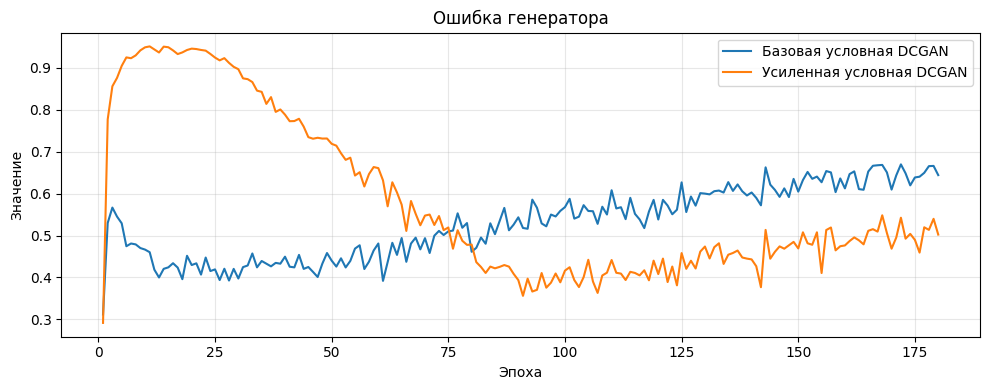

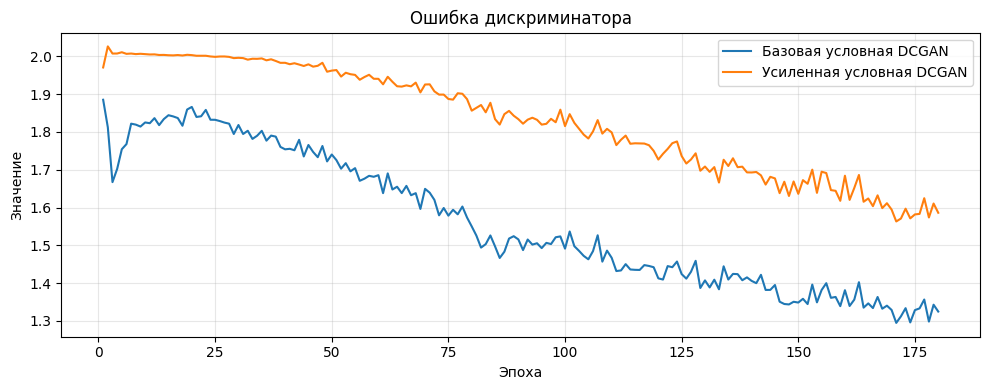

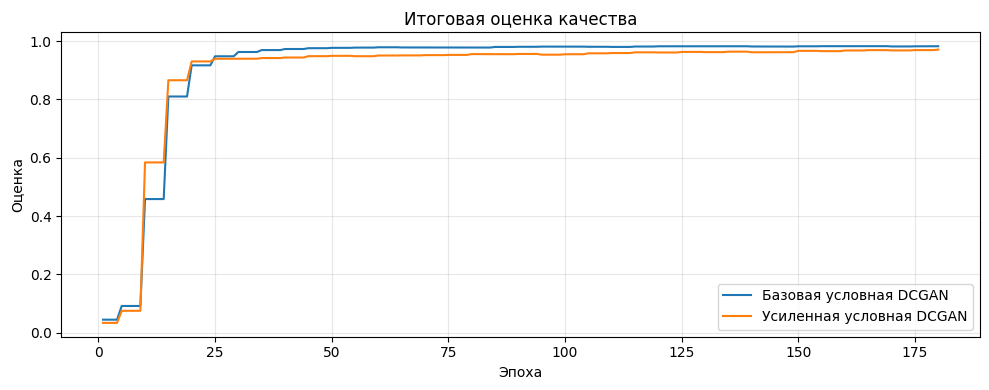

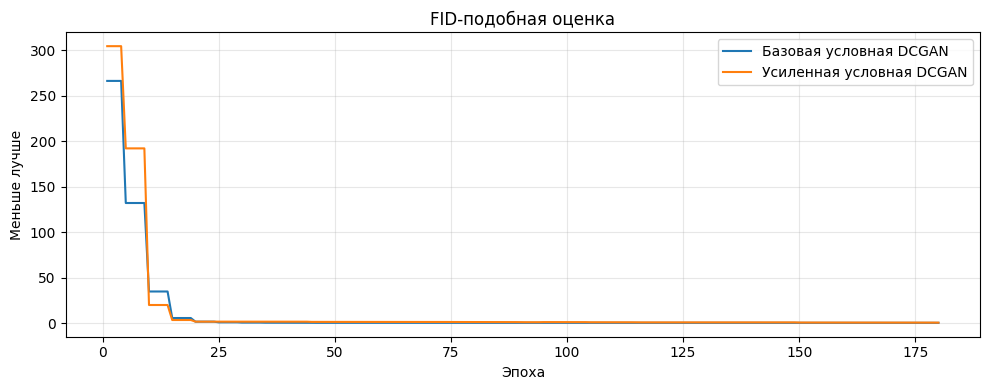

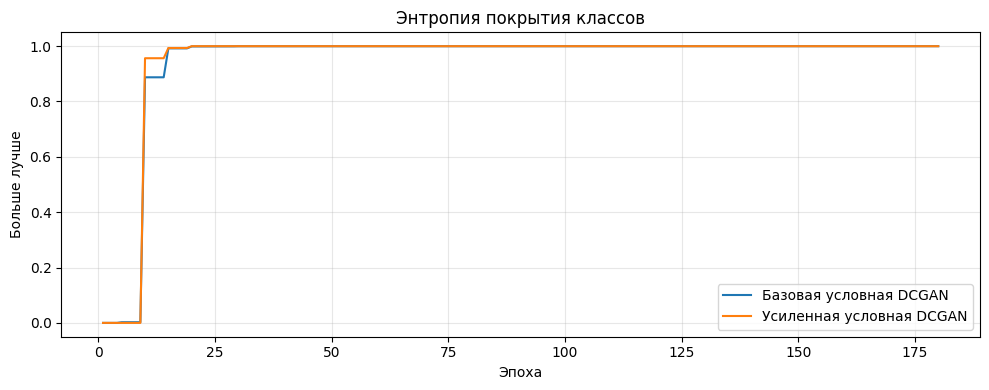

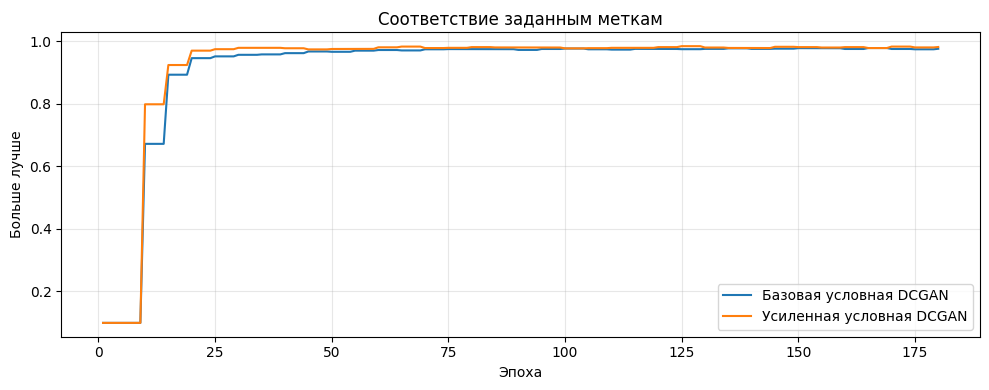

In [ ]:
def history_frame(trainer: ConditionalGanTrainer) -> pd.DataFrame:
    """Возвращает историю обучения в виде DataFrame."""
    frame = pd.DataFrame(trainer.history)
    return frame.sort_values("epoch").reset_index(drop=True)


def plot_metric_for_trainers(metric_name: str, title: str, ylabel: str) -> None:
    """Строит один график заданной метрики для всех моделей."""
    plt.figure(figsize=(10, 4))

    for trainer in trainers_by_key.values():
        frame = history_frame(trainer)
        if metric_name not in frame.columns:
            continue
        values = frame[metric_name].ffill()
        plt.plot(frame["epoch"], values, label=trainer.spec.title)

    plt.title(title)
    plt.xlabel("Эпоха")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_for_trainers("generator_loss", "Ошибка генератора", "Значение")
plot_metric_for_trainers("discriminator_loss", "Ошибка дискриминатора", "Значение")
plot_metric_for_trainers("quality_score", "Итоговая оценка качества", "Оценка")
plot_metric_for_trainers("fid_like", "FID-подобная оценка", "Меньше лучше")
plot_metric_for_trainers("coverage_entropy", "Энтропия покрытия классов", "Больше лучше")
plot_metric_for_trainers("label_match_rate", "Соответствие заданным меткам", "Больше лучше")


**График 1. Ошибка генератора**

На графике показана динамика функции потерь генератора для двух моделей. Для GAN эту кривую нельзя интерпретировать так же прямо, как обычную ошибку классификатора. Генератор обучается в состязании с дискриминатором, поэтому рост ошибки генератора не всегда означает ухудшение изображений. Часто это означает, что дискриминатор становится сильнее и предъявляет генератору более жесткие требования.

У базовой условной DCGAN ошибка сначала быстро поднимается, затем снижается примерно к диапазону 0.40-0.45, после чего постепенно растет до 0.60-0.66. Такая динамика выглядит нормальной для состязательного обучения. В начале генератор быстро находит грубые силуэты классов, затем дискриминатор становится увереннее, и генератору становится сложнее его обманывать. При этом рост ошибки во второй половине обучения не сопровождается ухудшением итоговых метрик, поэтому его нельзя считать признаком деградации.

У усиленной условной DCGAN ошибка генератора в первые эпохи резко возрастает почти до 0.95. Это показывает, что усиленный генератор на старте получает более жесткий сигнал от дискриминатора и обучается менее плавно. Затем ошибка постепенно снижается почти до 0.36-0.42, а к концу снова умеренно растет до 0.50-0.55. Такая форма говорит о более длительном поиске устойчивого режима. Усиленная модель сложнее, но в данной постановке эта сложность не дала явного выигрыша по качеству.

Главный вывод по графику: обе модели обучаются без признаков численной аварии, но базовая условная DCGAN выходит на более устойчивую траекторию быстрее. Ошибка генератора сама по себе не выбирает победителя, поэтому ее нужно анализировать вместе с FID-подобной оценкой, покрытием классов и визуальными примерами.

**График 2. Ошибка дискриминатора**

График показывает, как менялась функция потерь дискриминатора. В этой версии используется состязательное обучение с условным дискриминатором, поэтому дискриминатор оценивает не только реалистичность изображения, но и соответствие изображения заданной метке класса.

У базовой условной DCGAN ошибка дискриминатора после начального переходного участка постепенно снижается примерно с 1.85 до 1.30-1.35. Это означает, что дискриминатор становится лучше в различении реальных и сгенерированных изображений, а также лучше использует информацию о классе. Снижение достаточно плавное, без резких провалов и взрывов, что говорит о стабильном обучении.

У усиленной условной DCGAN ошибка дискриминатора выше почти на всем протяжении обучения. Она начинается около 2.0 и к концу снижается примерно до 1.58-1.62. Это значит, что для дискриминатора задача в случае усиленного генератора остается сложнее. Возможные причины: усиленный генератор создает более разнообразные промежуточные изображения, обучение идет менее линейно, а сама архитектура генератора требует больше эпох для стабилизации.

Важно, что обе кривые постепенно снижаются, а не уходят в хаотичные выбросы. Это хороший признак. Дискриминатор не разрушился и не перестал обучаться. При этом слишком быстрое падение ошибки дискриминатора могло бы говорить о доминировании дискриминатора, но здесь оно умеренное.

Главный вывод по графику: дискриминатор обучается стабильно для обеих моделей, но базовая модель формирует более простой для состязательного равновесия режим. Усиленная модель не проваливается, но требует большего вычислительного ресурса и не дает лучшего итогового качества.

**График 3. Итоговая оценка качества**

Этот график объединяет несколько аспектов качества генерации в одну итоговую оценку. В нее входят не только признаки реалистичности, но и покрытие классов, соответствие заданным меткам, разнообразие и штрафы за визуальные артефакты. Поэтому эта кривая лучше отражает практический прогресс обучения, чем отдельная ошибка генератора или дискриминатора.

В первые эпохи итоговая оценка быстро растет почти от нуля до значений выше 0.90. Это означает, что модели очень быстро переходят от случайного шума к изображениям, которые уже имеют узнаваемую классовую структуру. На датасете Fashion MNIST это ожидаемо. Изображения маленькие, одноканальные, с простыми силуэтами, поэтому грубая структура классов осваивается быстро.

После примерно 25-35 эпох обе модели выходят на плато около 0.96-0.98. Дальнейшее обучение уже не меняет результат радикально, а в основном уточняет детали и стабилизирует изображения. Базовая условная DCGAN почти на всем позднем участке находится немного выше усиленной модели. Это согласуется с финальной таблицей, где базовая модель получает лучшую итоговую оценку.

Главный вывод по графику: основное качество формируется в первой части обучения, а поздние эпохи работают как дообучение и стабилизация EMA-генератора. Плато на высоком уровне показывает, что обучение прошло успешно и без collapse.

**График 4. FID-подобная оценка**

FID-подобная оценка измеряет близость распределения признаков сгенерированных изображений к распределению признаков реальных изображений. Чем ниже значение, тем лучше. Это не настоящий FID на Inception-сети, а адаптированная версия для Fashion MNIST, рассчитанная в признаковом пространстве обученного оценочного классификатора.

В начале обучения значения очень большие: около 270-300. Это соответствует случайным или почти случайным изображениям, которые сильно отличаются от реальных объектов Fashion MNIST. Затем примерно за первые 15-25 эпох FID-подобная оценка резко падает почти к нулевому диапазону. Это говорит о быстром переходе генераторов от шума к распределению, похожему на реальные силуэты одежды.

После резкого падения график визуально становится почти плоским. Это связано с масштабом оси. Начальные значения очень велики, а поздние различия между моделями находятся уже в малом диапазоне. На этом графике трудно рассмотреть, что базовая модель в финале имеет FID-подобную оценку лучше усиленной. Для более детального анализа позднего участка полезно дополнительно строить этот график в логарифмической шкале или отдельно увеличивать диапазон после 25-й эпохи.

Главный вывод по графику: обе модели быстро научились попадать в распределение Fashion MNIST, а базовая условная DCGAN в финале оказалась немного ближе к реальному распределению признаков. Это один из ключевых аргументов в пользу базовой модели как победителя эксперимента.

**График 5. Энтропия покрытия классов**

Энтропия покрытия классов показывает, насколько равномерно генератор покрывает все 10 классов Fashion MNIST. Значение около 1.0 означает, что модель генерирует все классы почти равномерно. Значение около 0 означало бы collapse в один или несколько классов.

В первые эпохи энтропия почти нулевая. Это нормально, потому что генератор еще не научился управляемо создавать разные категории одежды. Затем примерно к 10-20 эпохам обе модели резко выходят к значениям, близким к 1.0. Это означает, что условная архитектура работает. Генераторы начинают создавать изображения для всех классов, а не только для наиболее простых категорий.

После выхода на уровень 1.0 график остается стабильным до конца обучения. Это важный результат, потому что в ранних версиях проекта отдельные классы выпадали, особенно класс ботинок. В финальной версии такой проблемы нет: классовое покрытие сохраняется на протяжении всего позднего обучения.

Главный вывод по графику: mode collapse по классам отсутствует. Обе модели научились покрывать все 10 классов, а условный дискриминатор и сбалансированная генерация меток успешно удерживают классовое разнообразие.

**График 6. Соответствие заданным меткам**

Этот график показывает, насколько часто оценочный классификатор относит сгенерированное изображение к тому классу, который был задан генератору. Например, если генератору задан класс сумка, хорошая модель должна сгенерировать изображение, которое классификатор тоже распознает как сумка.

В первые эпохи соответствие находится около 0.10, что соответствует случайному угадыванию для 10 классов. Это ожидаемая стартовая точка. Генератор еще не понимает условные метки и не умеет связывать их с визуальными признаками классов.

Затем метрика резко растет и примерно к 20-30 эпохам достигает уровня около 0.95-0.98. Это говорит о том, что генераторы быстро научились использовать условную информацию. После этого соответствие меткам остается высоким и стабильным до конца обучения. Усиленная условная DCGAN местами немного выше базовой модели, но разница небольшая и не компенсирует ее проигрыш по FID-подобной оценке и скорости.

Главный вывод по графику: условная генерация работает корректно. Модели не просто создают похожие на одежду изображения, а в большинстве случаев создают именно тот класс, который был запрошен. Самые частые ошибки ожидаемо возникают между визуально похожими категориями: рубашка, футболка или топ, пуловер и пальто.

**Общий вывод по всем графикам**

Все шесть графиков согласуются между собой. В начале обучения обе модели быстро переходят от шума к осмысленным силуэтам. Затем метрики покрытия классов и соответствия меткам выходят на высокий уровень, а FID-подобная оценка резко снижается. Это означает, что обучение успешно решило две главные задачи: реалистичность и управляемость по классу.

Базовая условная DCGAN показывает лучший баланс. Она быстрее стабилизируется, имеет более низкую FID-подобную оценку и лучшую итоговую оценку качества. Усиленная условная DCGAN тоже обучается корректно и хорошо покрывает классы, но ее дополнительная архитектурная сложность не дала преимущества в этом эксперименте.

Исследовательский вывод: для Fashion MNIST при разрешении 28x28 базовая условная DCGAN оказалась более эффективной, чем усиленная архитектура: она проще, быстрее и дает немного лучшее качество по совокупности метрик.

## 26. Диагностика градиентов и скорости

Этот раздел проверяет устойчивость обучения и производительность. Он показывает, сколько эпох завершено, почему обучение остановилось, какова доля существующих и конечных градиентов, а также сколько времени занимает эпоха.

Нормы градиентов отображаются как диагностические графики. При mixed precision они могут быть рваными, потому что связаны с масштабированием функции потерь. Это не ошибка, если доля существующих и конечных градиентов близка к 1, а потери остаются конечными.

Главная задача раздела - подтвердить, что обучение реально шло на всем протяжении эксперимента и не было скрытого разрушения чисел.


,модель,эпох_завершено,причина_завершения,min_g_grad_present,min_d_grad_present,min_g_grad_finite,min_d_grad_finite,среднее_время_эпохи_сек
0,Базовая условная DCGAN,180,max_epochs,1.0,1.0,0.999621,0.999587,18.400121
1,Усиленная условная DCGAN,180,max_epochs,1.0,1.0,0.999784,0.999174,30.975669


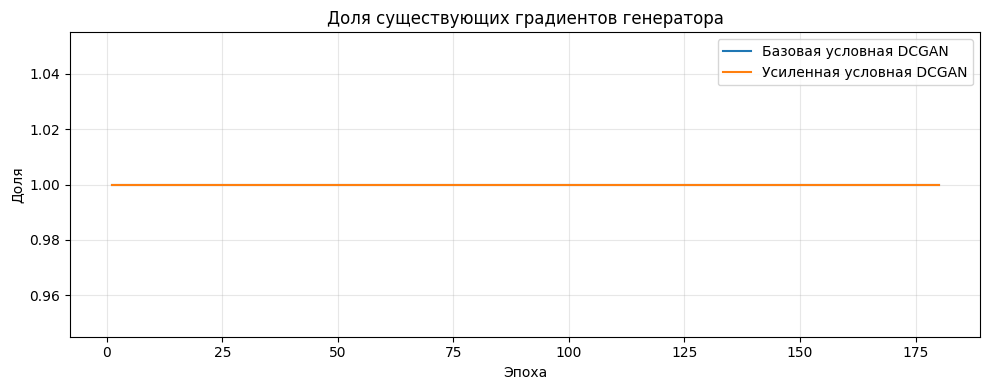

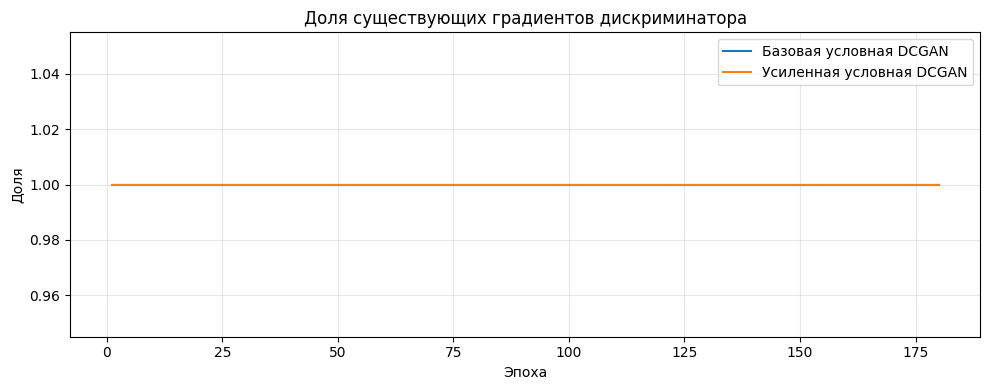

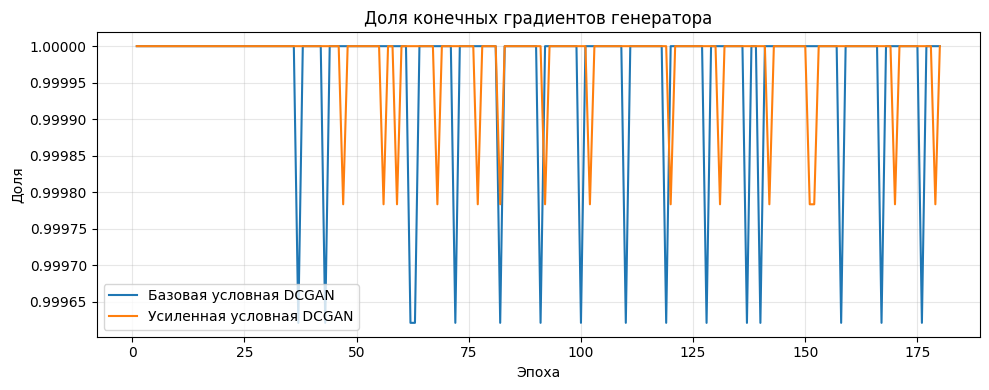

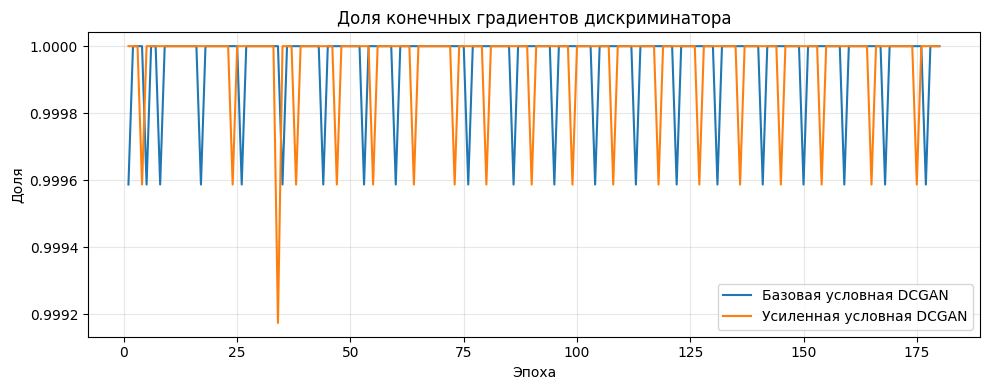

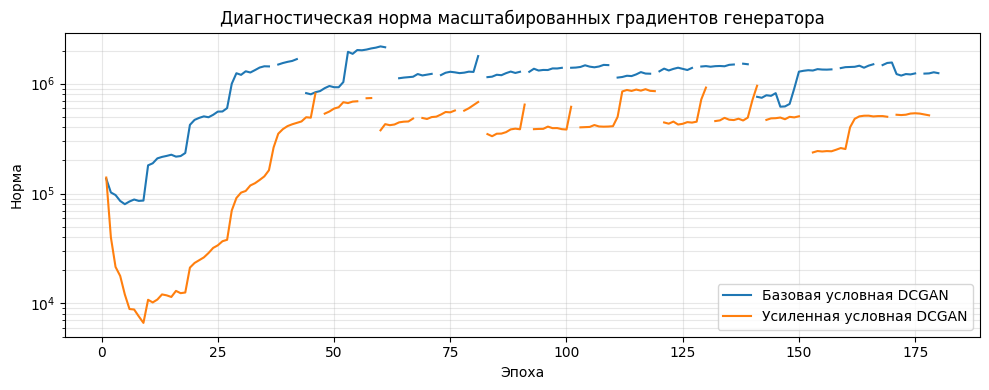

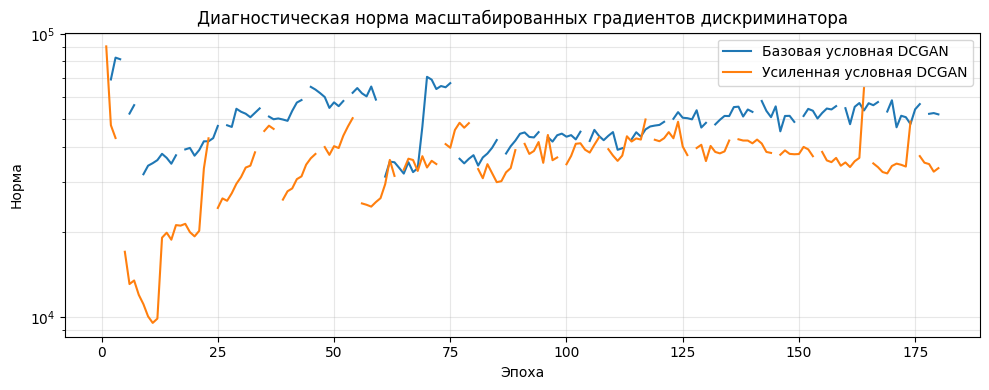

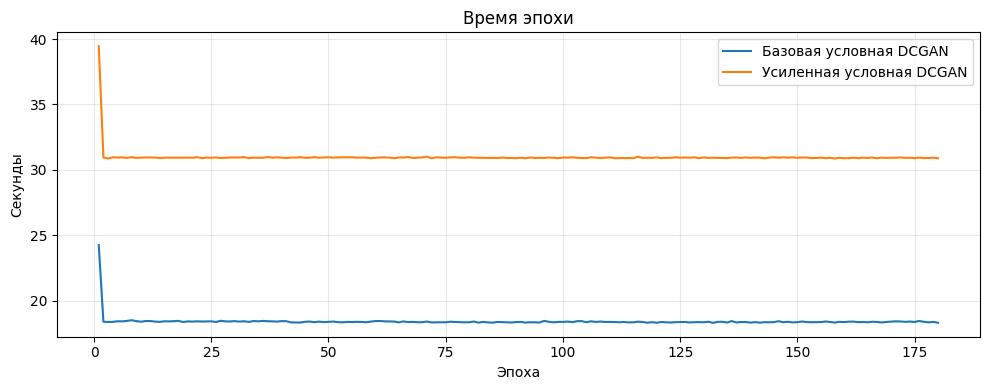

In [ ]:
def summarize_training_stability(trainers: Dict[str, ConditionalGanTrainer]) -> pd.DataFrame:
    """Собирает таблицу устойчивости обучения по всем моделям."""
    rows = []

    for trainer in trainers.values():
        frame = history_frame(trainer)
        rows.append(
            {
                "модель": trainer.spec.title,
                "эпох_завершено": int(frame["epoch"].max()),
                "причина_завершения": trainer.stop_reason,
                "min_g_grad_present": float(frame["generator_gradient_present_ratio"].min()),
                "min_d_grad_present": float(frame["discriminator_gradient_present_ratio"].min()),
                "min_g_grad_finite": float(frame["generator_gradient_finite_ratio"].min()),
                "min_d_grad_finite": float(frame["discriminator_gradient_finite_ratio"].min()),
                "среднее_время_эпохи_сек": float(frame["seconds"].mean()),
            }
        )

    return pd.DataFrame(rows)


def safe_history_series(frame: pd.DataFrame, metric_name: str) -> pd.Series:
    """Готовит ряд метрики для построения устойчивых графиков."""
    # pd.to_numeric переводит случайные строковые значения в числа, а ошибки заменяет на NaN.
    values = pd.to_numeric(frame[metric_name], errors="coerce")

    # Бесконечные значения не должны попадать на график, иначе масштаб оси становится нечитаемым.
    values = values.replace([np.inf, -np.inf], np.nan)
    return values


def plot_metric_for_trainers_safe(metric_name: str, title: str, ylabel: str) -> None:
    """Строит обычный график метрики с безопасной обработкой пропусков."""
    plt.figure(figsize=(10, 4))

    for trainer in trainers_by_key.values():
        frame = history_frame(trainer)
        if metric_name not in frame.columns:
            continue

        # Для редких метрик используем протяжку последнего значения вперед.
        values = safe_history_series(frame, metric_name).ffill()
        plt.plot(frame["epoch"], values, label=trainer.spec.title)

    plt.title(title)
    plt.xlabel("Эпоха")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_log_metric_for_trainers(metric_name: str, title: str, ylabel: str) -> None:
    """Строит логарифмический график положительной диагностической метрики."""
    plt.figure(figsize=(10, 4))

    for trainer in trainers_by_key.values():
        frame = history_frame(trainer)
        if metric_name not in frame.columns:
            continue

        values = safe_history_series(frame, metric_name)

        # Логарифмическая шкала определена только для положительных значений.
        values = values.where(values > 0)
        plt.semilogy(frame["epoch"], values, label=trainer.spec.title)

    plt.title(title)
    plt.xlabel("Эпоха")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()


stability_table = summarize_training_stability(trainers_by_key)
stability_table.to_csv(TABLE_DIR / "training_stability.csv", index=False)
display(stability_table)

# Главная диагностика: градиенты должны существовать и оставаться конечными почти во все эпохи.
plot_metric_for_trainers_safe("generator_gradient_present_ratio", "Доля существующих градиентов генератора", "Доля")
plot_metric_for_trainers_safe("discriminator_gradient_present_ratio", "Доля существующих градиентов дискриминатора", "Доля")
plot_metric_for_trainers_safe("generator_gradient_finite_ratio", "Доля конечных градиентов генератора", "Доля")
plot_metric_for_trainers_safe("discriminator_gradient_finite_ratio", "Доля конечных градиентов дискриминатора", "Доля")

# Нормы градиентов оставлены как дополнительная диагностика, а не как критерий качества генерации.
plot_log_metric_for_trainers("generator_gradient_norm", "Диагностическая норма масштабированных градиентов генератора", "Норма")
plot_log_metric_for_trainers("discriminator_gradient_norm", "Диагностическая норма масштабированных градиентов дискриминатора", "Норма")
plot_metric_for_trainers_safe("seconds", "Время эпохи", "Секунды")


**График 1. Доля существующих градиентов генератора**

На графике показана доля параметров генератора, для которых во время обратного распространения ошибки были получены градиенты. Значение 1.0 означает, что все обучаемые параметры генератора участвуют в обновлении.

Обе линии идут ровно на уровне 1.0 на всем протяжении обучения. Это хороший результат. Он означает, что в графе вычислений нет разрывов. Генератор связан с функцией потерь, все его слои получают сигнал обучения, а оптимизатор действительно имеет что обновлять.

Это особенно важно для пользовательского цикла обучения GAN. В предыдущих версиях была опасность ситуации, когда обучение формально запускается, но часть градиентов отсутствует из-за неправильной работы GradientTape или смешанной точности. Этот график показывает, что в финальной версии такой проблемы нет.

Вывод: генератор обеих моделей обучается корректно, все его параметры получают градиенты.

**График 2. Доля существующих градиентов дискриминатора**

Этот график аналогичен предыдущему, но относится к дискриминатору. Он показывает, для какой доли параметров дискриминатора были получены градиенты на каждой эпохе.

Обе модели снова дают стабильное значение 1.0. Это означает, что дискриминатор полностью включен в обучение: сверточные блоки, слой условного вложения класса и проекционная часть дискриминатора получают обучающий сигнал.

Для условного проекционного дискриминатора это принципиально важно. Если бы градиенты не доходили до слоя классового вложения, дискриминатор мог бы игнорировать метки классов, а генератор снова начал бы терять управляемость по классам. Здесь этого не происходит.

Вывод: дискриминатор обеих моделей обучается полноценно, включая условную часть, отвечающую за связь изображения с меткой класса.

**График 3. Доля конечных градиентов генератора**

На этом графике показана доля элементов градиентов генератора, которые имеют конечные числовые значения, то есть не являются NaN или Inf.

График визуально выглядит рваным, но это связано с очень узким масштабом оси Y. Значения находятся примерно в диапазоне от 0.9996 до 1.0. Это означает, что даже в худшие моменты конечными остаются более 99.96% элементов градиентов. Фактически это очень высокий показатель численной устойчивости.

Небольшие кратковременные провалы допустимы при использовании mixed_float16 и масштабирования функции потерь. При смешанной точности оптимизатор работает с масштабированными градиентами, и отдельные элементы могут временно становиться нечисловыми. Важно, что эти провалы не превращаются в системную деградацию: линия постоянно возвращается к 1.0, потери не становятся NaN, а итоговые изображения получаются качественными.

У базовой модели провалы чуть глубже и встречаются чаще. Это не выглядит критично, потому что финальная устойчивость обучения подтверждается остальными метриками.

Вывод: градиенты генератора почти полностью конечны; небольшие провалы являются диагностическим эффектом смешанной точности, а не ошибкой обучения.

**График 4. Доля конечных градиентов дискриминатора**

График показывает долю конечных элементов градиентов дискриминатора.

Здесь рваность заметнее, чем у генератора, но масштаб снова очень узкий. Значения остаются примерно выше 0.9992. Это значит, что даже при самых сильных просадках нечисловыми становятся доли процента элементов градиентов. Для GAN с проекционным дискриминатором и смешанной точностью это приемлемо.

Дискриминатор получает более сложный сигнал, чем генератор. Он работает с реальными изображениями, сгенерированными изображениями и условной связью с метками классов. Поэтому его градиенты могут быть более резкими. Также дискриминатор обычно быстрее реагирует на изменения генератора, что делает его диагностические кривые менее гладкими.

Самое важное - нет длительного падения доли конечных градиентов, нет ухода к значениям вроде 0.9, 0.5 или 0.0, нет признаков численного разрушения модели.

Вывод: дискриминатор обучается численно устойчиво; краткие провалы конечности градиентов не мешают обучению и не указывают на аварию.

**График 5. Диагностическая норма масштабированных градиентов генератора**

Этот график показывает норму масштабированных градиентов генератора. Он построен в логарифмической шкале, поэтому вертикальные изменения выглядят резкими, даже если они находятся в рабочем диапазоне.

Важно: это не обычная норма градиентов, а диагностическая норма после масштабирования, используемого при mixed_float16. Поэтому абсолютные значения нельзя напрямую сравнивать с нормами градиентов в обычном float32-обучении. Этот график нужен не для выбора лучшей модели, а для проверки, что градиентный сигнал существует и не исчезает.

У базовой условной DCGAN норма градиентов генератора быстро растет в начале обучения и затем держится примерно в диапазоне 10^6. Это говорит о сильном и стабильном обучающем сигнале. Видимые разрывы связаны с фильтрацией нечисловых или неположительных значений перед построением логарифмического графика, а также с особенностями масштабирования потерь.

У усиленной условной DCGAN в начале есть сильное снижение нормы, затем постепенный рост и выход на более умеренный диапазон. Это соответствует поведению более сложной архитектуры: она дольше стабилизируется и на ранних этапах получает менее ровный сигнал. Тем не менее к середине обучения сигнал становится устойчивым.

Вывод: градиентный сигнал генератора не исчезает у обеих моделей; базовая модель получает более сильный и стабильный сигнал, что согласуется с ее лучшим итоговым качеством.

**График 6. Диагностическая норма масштабированных градиентов дискриминатора**

График показывает норму масштабированных градиентов дискриминатора в логарифмической шкале.

В отличие от графика генератора, нормы дискриминатора находятся в более узком диапазоне, в основном между 10^4 и 10^5. Это хороший признак: дискриминатор не демонстрирует взрывного роста градиентов на несколько порядков и не уходит в область исчезающих градиентов.

В начале у усиленной модели виден резкий спад нормы, затем постепенное восстановление. Это можно интерпретировать как фазу первичной адаптации дискриминатора к более сложному генератору. У базовой модели кривая в среднем выше и чуть стабильнее, что показывает более уверенное состязательное равновесие.

Разрывы и скачки на графике не являются самостоятельной проблемой. Это диагностический график масштабированных градиентов при смешанной точности, а не показатель качества изображений. Важнее то, что значения остаются в контролируемом диапазоне, а доля существующих и конечных градиентов на предыдущих графиках близка к 1.0.

Вывод: дискриминатор получает устойчивый обучающий сигнал; признаков взрыва или исчезновения градиентов нет.

**График 7. Время эпохи**

График показывает время выполнения одной эпохи для двух моделей.

Первая эпоха заметно медленнее у обеих моделей. Это нормально: в начале TensorFlow выполняет трассировку tf.function, подготавливает граф вычислений, прогревает конвейер данных, инициализирует операции на GPU и заполняет кэш данных.

После первой эпохи время становится почти идеально стабильным. Это хороший технический признак. Он показывает, что:

- конвейер tf.data работает ровно;
- нет нарастающих утечек памяти;
- нет заметных простоев между эпохами;
- граф вычислений не пересобирается каждый раз;
- GPU получает данные стабильно.

Базовая условная DCGAN обучается примерно за 18-19 секунд на эпоху. Усиленная условная DCGAN обучается примерно за 31 секунду на эпоху. Разница ожидаема: усиленный генератор содержит больше операций и требует больше вычислений.

При этом усиленная модель не дала лучшего итогового качества, хотя стоила примерно в 1.6-1.7 раза дороже по времени эпохи. Это важный исследовательский результат. Для Fashion MNIST с изображениями 28x28 более сложная архитектура не окупила дополнительную вычислительную стоимость.

Вывод: обучение технически стабильно, GPU-конвейер работает ровно, а базовая условная DCGAN дает лучший баланс качества и скорости.

**Общий вывод по диагностическим графикам**

Эти графики подтверждают, что финальное обучение прошло корректно. У обеих моделей:

- все параметры генератора получают градиенты;
- все параметры дискриминатора получают градиенты;
- почти все элементы градиентов остаются конечными;
- нет признаков численного разрушения;
- нет исчезновения градиентного сигнала;
- нет взрыва градиентов на длительном участке;
- время эпохи стабильно после начального прогрева.

Рваность графиков конечных и масштабированных градиентов не является ошибкой модели. Она объясняется сочетанием трех факторов: очень узким масштабом оси, смешанной точностью mixed_float16 и отображением масштабированных, а не обычных градиентов.

Главный исследовательский вывод: диагностика подтверждает надежность тренировочного цикла, а различие во времени эпохи показывает, что базовая условная DCGAN эффективнее усиленной модели в данной задаче.

## 27. Финальная оценка лучших EMA-генераторов

В этом блоке оцениваются лучшие EMA-генераторы обеих моделей. Именно EMA-версия используется для финальных результатов, потому что она сглаживает колебания весов и обычно дает более стабильные изображения.

Финальная таблица объединяет все основные метрики. FID-подобная оценка показывает близость признакового распределения к реальному. Покрытие классов и минимальная доля класса показывают, не выпадают ли категории. Соответствие заданным меткам оценивает условность генерации.

Также учитываются признаки пиксельных артефактов: полная вариация и доля сильных перепадов. Это защищает исследование от ситуации, когда модель формально распознается классификатором, но визуально создает шум.


In [ ]:
def evaluate_final_generators(
    trainers: Dict[str, ConditionalGanTrainer],
    evaluator: QualityEvaluator,
    config: ExperimentConfig,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, np.ndarray]]]:
    """Считает финальные метрики и сохраняет подробные данные для визуализаций."""
    rows = []
    details_by_key = {}

    for key, trainer in trainers.items():
        metrics, details = evaluator.evaluate(
            trainer.ema_generator,
            sample_count=config.final_eval_samples,
            return_details=True,
        )
        row = {"model_key": key, "модель": trainer.spec.title, **metrics}
        rows.append(row)
        details_by_key[key] = details

    metrics_frame = pd.DataFrame(rows).sort_values("quality_score", ascending=False).reset_index(drop=True)
    metrics_frame.to_csv(TABLE_DIR / "final_metrics.csv", index=False)
    return metrics_frame, details_by_key


final_metrics, final_details_by_key = evaluate_final_generators(trainers_by_key, quality_evaluator, CONFIG)
display(final_metrics)


,model_key,модель,fid_like,coverage_entropy,label_match_rate,min_class_share,missing_class_count,min_condition_match,feature_diversity_ratio,tv_ratio,high_contrast_ratio,mean_confidence,quality_score
0,basic,Базовая условная DCGAN,0.183135,0.999842,0.976500,0.095000,0.0,0.925,1.014629,0.958862,0.950414,0.965478,0.984047
1,enhanced,Усиленная условная DCGAN,0.471432,0.999899,0.978333,0.095333,0.0,0.935,1.042971,0.906844,0.949999,0.966196,0.970890


Финальная таблица показывает, что обе модели успешно прошли основные проверки. У базовой модели FID-подобная оценка **0.1831**, итоговая оценка **0.9840**, покрытие классов **0.9998**, соответствие меткам **0.9765** и нет пропущенных классов.

У усиленной модели FID-подобная оценка **0.4714**, итоговая оценка **0.9709**, покрытие классов **0.9999**, соответствие меткам **0.9783** и также нет пропущенных классов.

Базовая модель выигрывает по FID-подобной оценке и итоговому качеству. Усиленная модель немного лучше по покрытию классов и соответствию меткам, но этот выигрыш очень мал и не компенсирует более низкую FID-подобную оценку и большую вычислительную стоимость.

Исследовательский вывод: на Fashion MNIST усложнение генератора не дало практического выигрыша. Компактная условная DCGAN оказалась эффективнее.


## 28. Таблица качества по классам

Этот блок детализирует финальную оценку по каждому из 10 классов Fashion MNIST. Общая метрика может скрыть слабые категории, поэтому для условной генерации обязательно смотреть классы отдельно.

В таблице есть две ключевые величины: доля предсказанного класса среди всех сгенерированных изображений и соответствие заданной метке внутри каждого класса. Первая величина показывает баланс, вторая - насколько генератор следует условию.

Особое внимание стоит уделять классам верхней одежды, потому что они визуально похожи между собой и часто становятся самыми трудными для классификатора и генератора.


In [ ]:
def build_per_class_metrics(details_by_key: Dict[str, Dict[str, np.ndarray]]) -> pd.DataFrame:
    """Формирует таблицу качества по каждому классу."""
    rows = []

    for key, details in details_by_key.items():
        trainer = trainers_by_key[key]
        class_shares = details["class_shares"]
        condition_match = details["condition_match_by_class"]

        for class_id, class_name in enumerate(CLASS_NAMES):
            rows.append(
                {
                    "model_key": key,
                    "модель": trainer.spec.title,
                    "class_id": class_id,
                    "класс": class_name,
                    "доля_предсказанного_класса": float(class_shares[class_id]),
                    "соответствие_заданной_метке": float(condition_match[class_id]),
                }
            )

    return pd.DataFrame(rows)


per_class_metrics = build_per_class_metrics(final_details_by_key)
per_class_metrics.to_csv(TABLE_DIR / "per_class_metrics.csv", index=False)
display(per_class_metrics)


,model_key,модель,class_id,класс,доля_предсказанного_класса,соответствие_заданной_метке
0,basic,Базовая условная DCGAN,0,футболка или топ,0.095000,0.936667
1,basic,Базовая условная DCGAN,1,брюки,0.100167,1.000000
2,basic,Базовая условная DCGAN,2,пуловер,0.097667,0.958333
3,basic,Базовая условная DCGAN,3,платье,0.099333,0.981667
4,basic,Базовая условная DCGAN,4,пальто,0.106167,0.978333
5,basic,Базовая условная DCGAN,5,сандалия,0.099167,0.991667
6,basic,Базовая условная DCGAN,6,рубашка,0.101667,0.925000
7,basic,Базовая условная DCGAN,7,кроссовок,0.100833,0.996667
8,basic,Базовая условная DCGAN,8,сумка,0.100000,1.000000
9,basic,Базовая условная DCGAN,9,ботинок,0.100000,0.996667


Таблица подтверждает, что ни один класс не выпал. Для базовой модели доли классов находятся примерно в диапазоне от `0.0950` до `0.1062`, для усиленной - примерно от `0.0953` до `0.1038`. Это близко к равномерному распределению 0.10.

Самым слабым классом по соответствию метке у обеих моделей стала `рубашка`: `0.9250` у базовой модели и `0.9350` у усиленной. Это ожидаемо, потому что рубашка визуально пересекается с футболкой, пуловером и пальто.

Классы `брюки`, `сумка`, `кроссовок` и `ботинок` распознаются почти идеально. Значит, условный сигнал хорошо работает для классов с выраженным силуэтом.


## 29. Визуальное сравнение по классам

Этот блок строит сетки условной генерации. Каждая строка соответствует одному классу, а столбцы показывают разные примеры этого класса. Такая визуализация является обязательной для GAN, потому что численные метрики не полностью описывают визуальное качество.

Сетка отвечает на несколько вопросов: появляются ли все классы, сохраняется ли условие класса, есть ли mode collapse, похожи ли изображения на реальные объекты Fashion MNIST, нет ли чрезмерного шума или штрих-кодных паттернов.

Для финального вывода важно, чтобы обе модели создавали узнаваемые силуэты во всех строках, а не только хорошо показывали один или два класса.


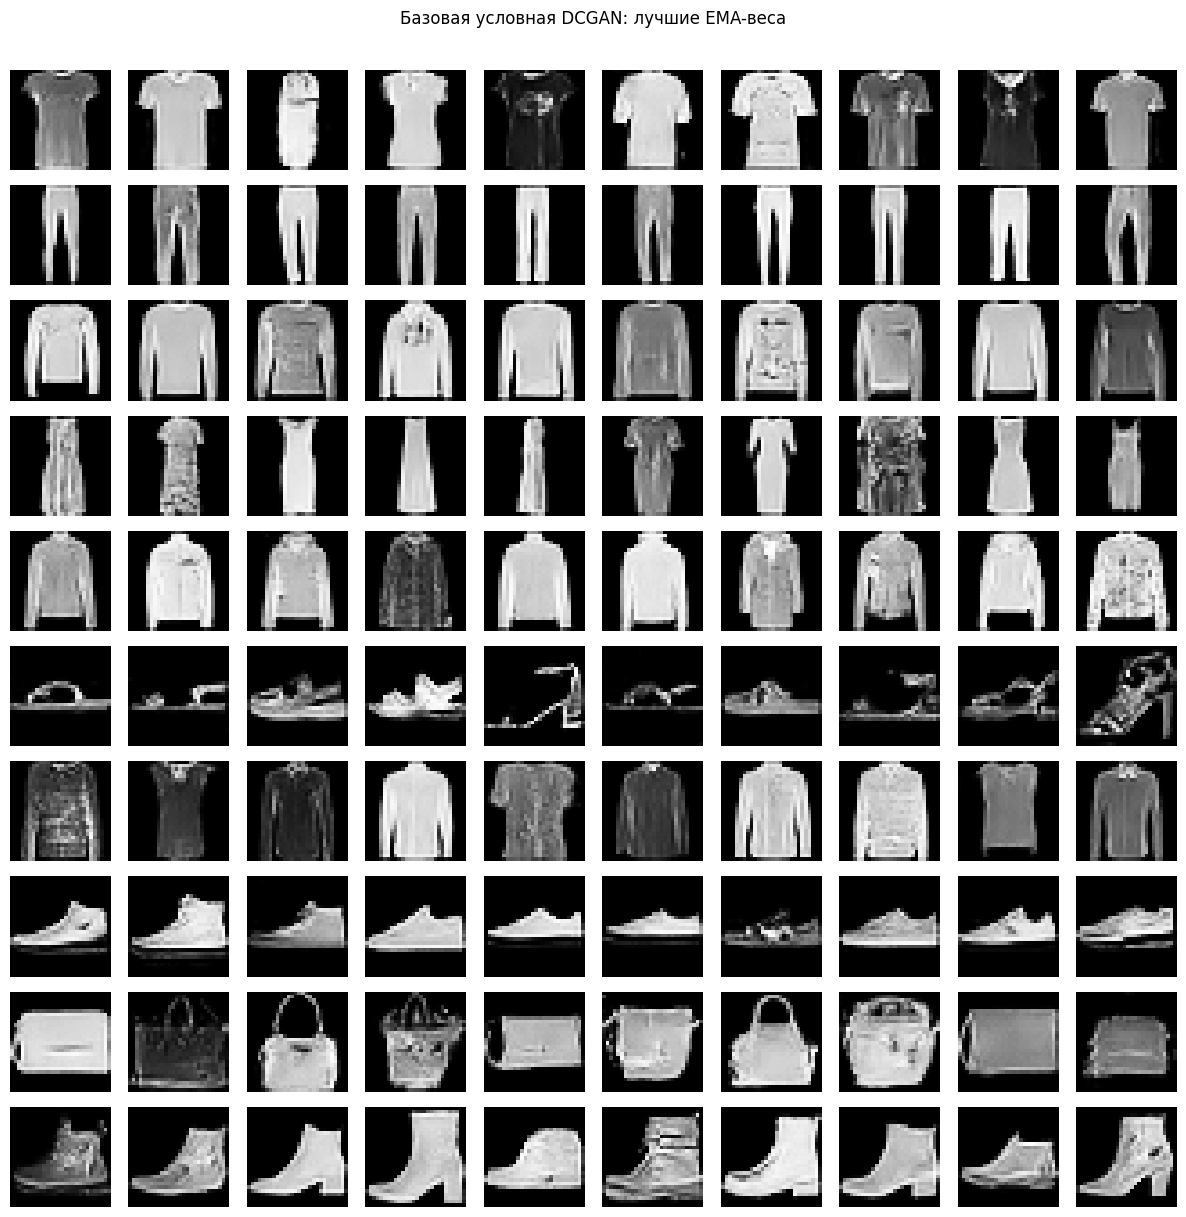

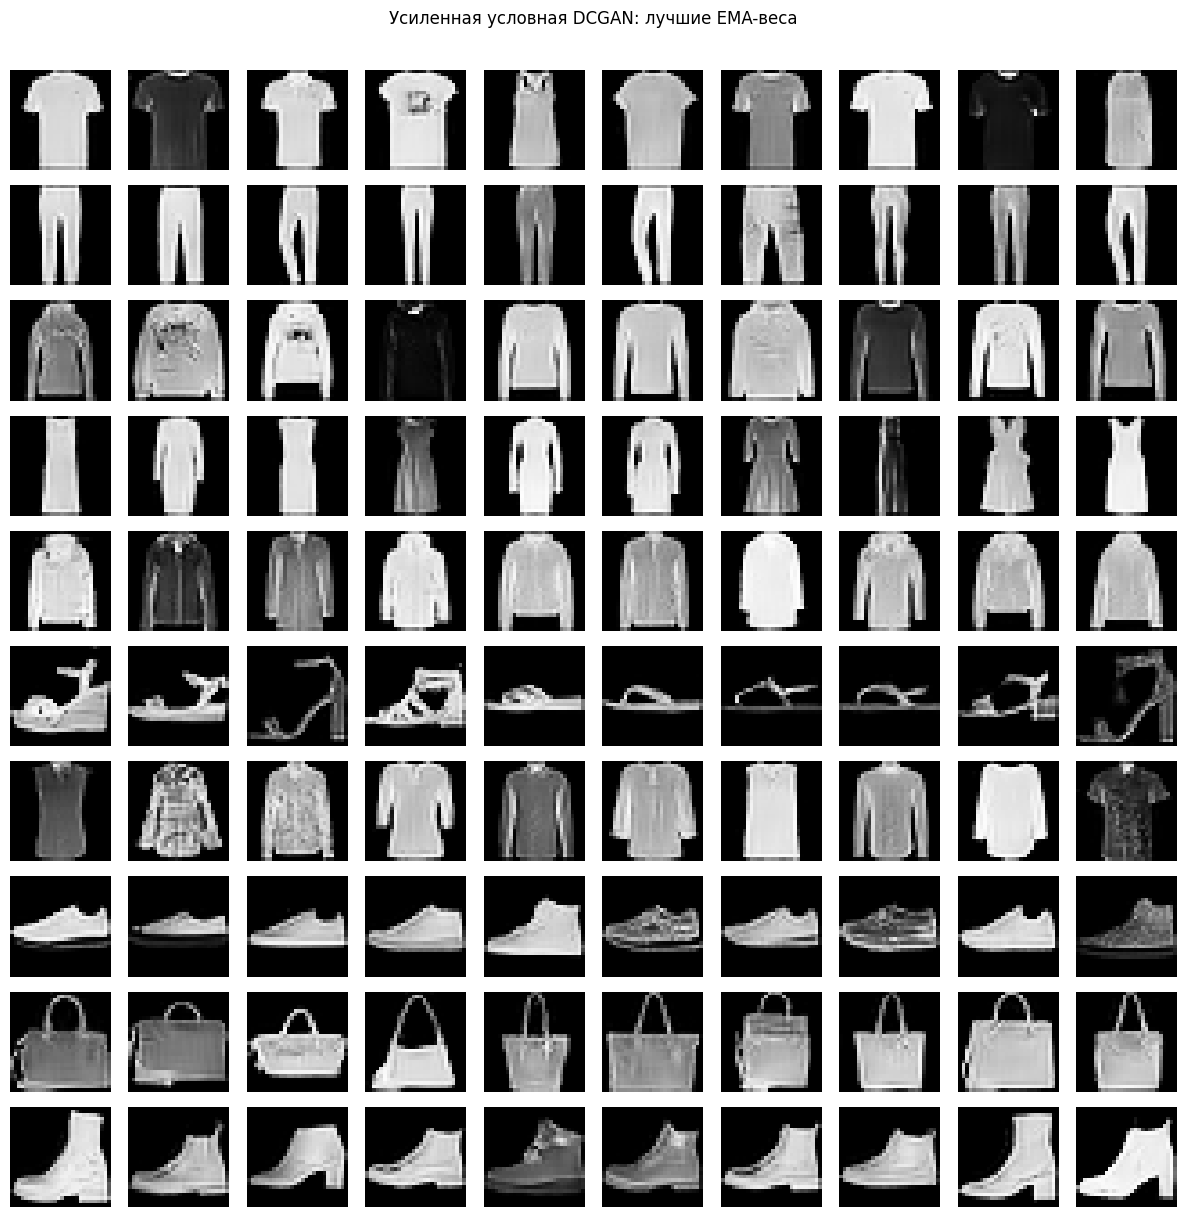

In [ ]:
def show_conditioned_grid(
    generator: keras.Model,
    title: str,
    samples_per_class: int,
    config: ExperimentConfig,
    save_path: Optional[Path] = None,
) -> None:
    """Показывает сетку изображений, сгенерированных по всем классам."""
    labels = np.repeat(np.arange(config.num_classes), samples_per_class).astype("int32")
    noise = tf.random.normal([len(labels), config.latent_dim], seed=config.seed)
    images = generator([noise, tf.convert_to_tensor(labels)], training=False).numpy()
    images_01 = gan_to_classifier_range(images)

    fig, axes = plt.subplots(config.num_classes, samples_per_class, figsize=(samples_per_class * 1.2, config.num_classes * 1.2))

    for row, class_name in enumerate(CLASS_NAMES):
        for col in range(samples_per_class):
            image_index = row * samples_per_class + col
            ax = axes[row, col]
            ax.imshow(images_01[image_index, :, :, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=55, va="center")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


for key, trainer in trainers_by_key.items():
    show_conditioned_grid(
        trainer.ema_generator,
        title=f"{trainer.spec.title}: лучшие EMA-веса",
        samples_per_class=CONFIG.grid_samples_per_class,
        config=CONFIG,
        save_path=IMAGE_DIR / f"{key}_conditioned_grid.png",
    )


Визуальные сетки подтверждают численные метрики. Обе модели создают узнаваемые изображения всех 10 классов. Нет полного шума, нет mode collapse и нет выпадения класса `ботинок`.

У базовой модели изображения выглядят достаточно четкими для Fashion MNIST. Она хорошо передает силуэты брюк, обуви, сумок и большей части верхней одежды. У сложных классов верхней одежды видны небольшие шумовые текстуры, но объект остается узнаваемым.

Усиленная модель также генерирует все классы, но не демонстрирует очевидного визуального преимущества. С учетом большего времени обучения и худшей FID-подобной оценки ее усложнение не выглядит оправданным для этого датасета.


## 30. Интерполяция в скрытом пространстве по всем классам

Интерполяция показывает, как генератор меняет изображение при плавном изменении скрытого вектора. В хорошей модели изменения должны быть постепенными: силуэт, толщина, наклон или детализация меняются плавно, а класс сохраняется.

Блок выполняет интерполяцию сразу для всех классов. Это универсальная проверка, а не подбор под отдельную категорию. Она помогает понять, изучил ли генератор непрерывное пространство образов или просто выдает набор разрозненных шаблонов.

Если при интерполяции появляются резкие скачки, шум или исчезновение объекта, это указывает на проблемы в скрытом пространстве.


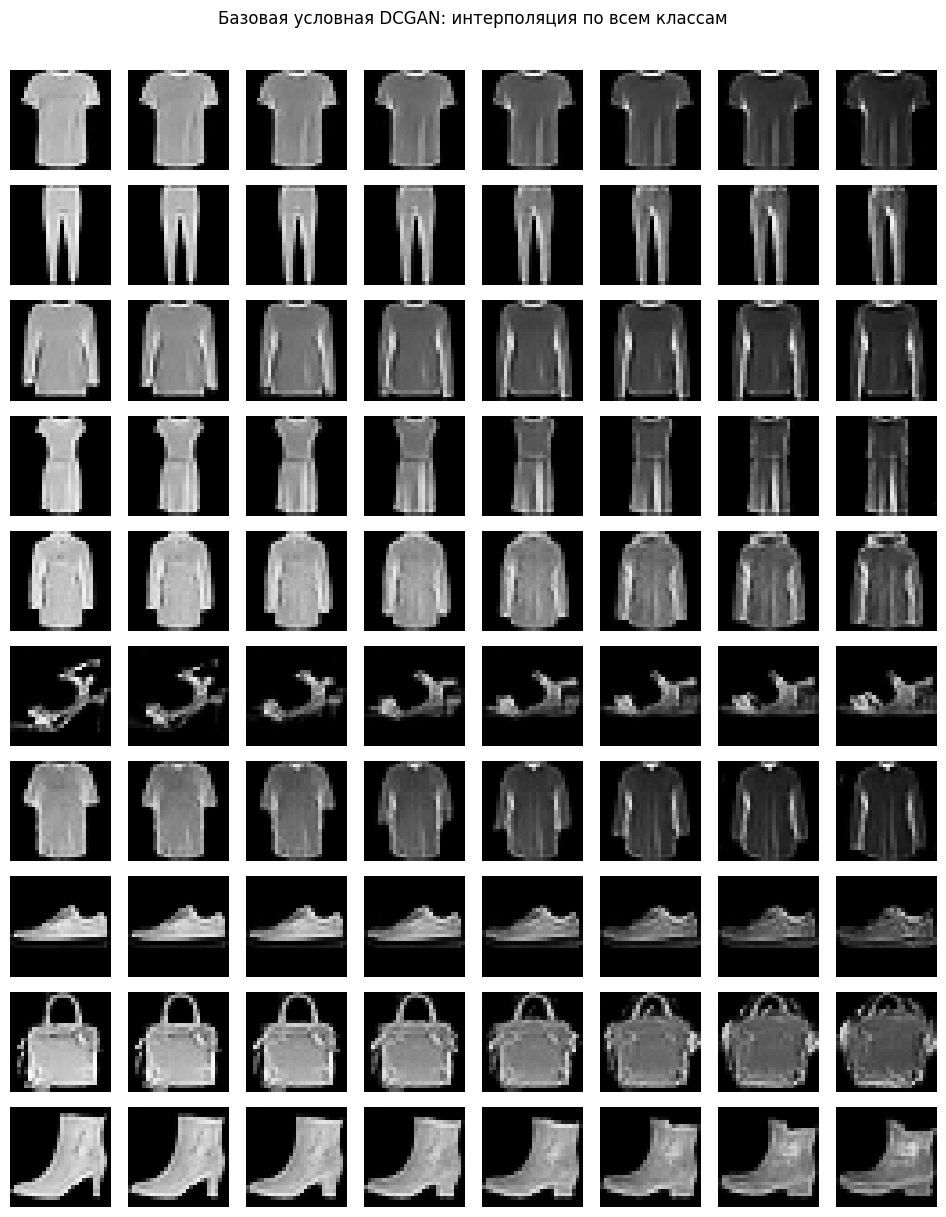

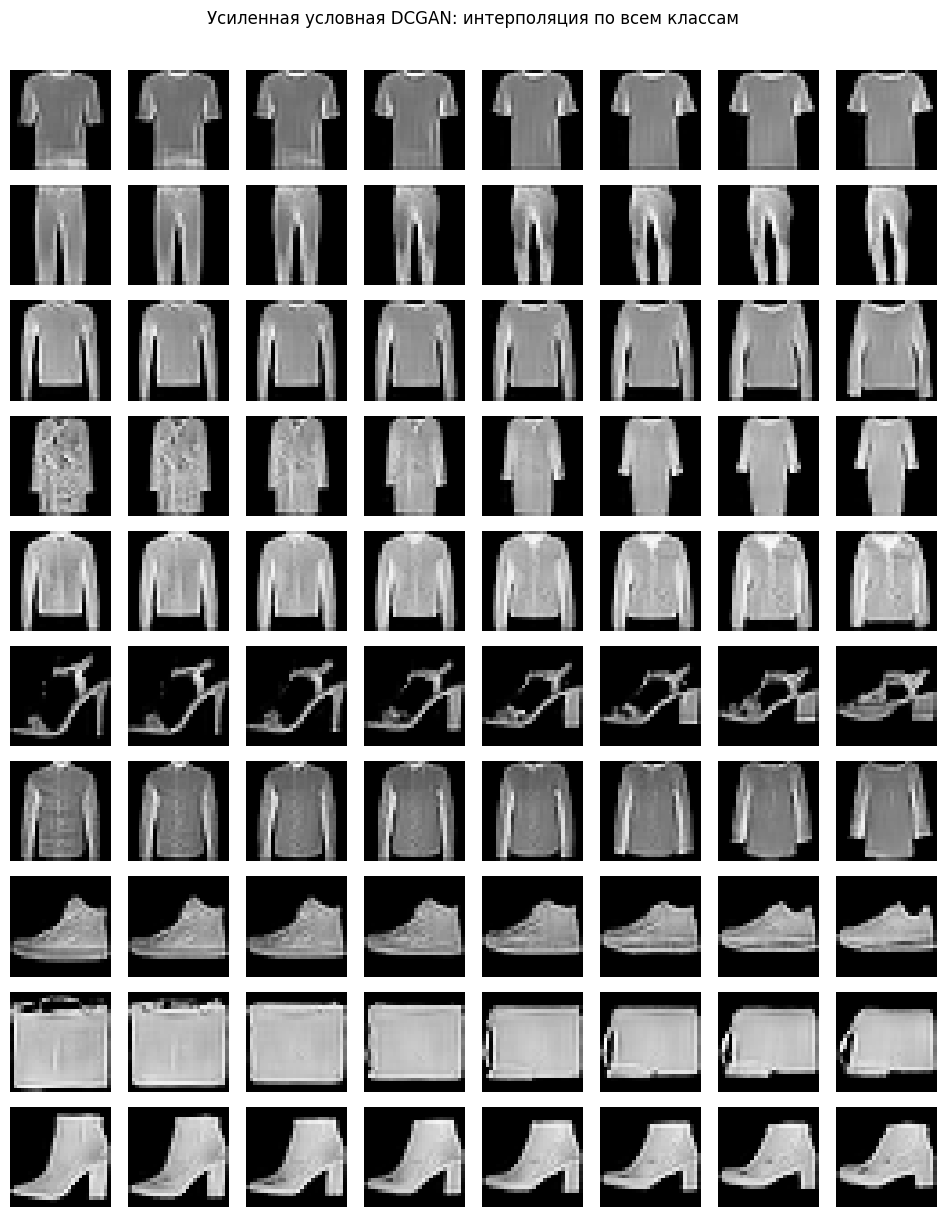

In [ ]:
def show_all_class_interpolation(
    generator: keras.Model,
    title: str,
    config: ExperimentConfig,
    interpolation_steps: int = 8,
    save_path: Optional[Path] = None,
) -> None:
    """Показывает интерполяцию между двумя точками скрытого пространства для всех классов."""
    start_noise = tf.random.normal([1, config.latent_dim], seed=config.seed + 11)
    end_noise = tf.random.normal([1, config.latent_dim], seed=config.seed + 17)
    weights = tf.linspace(0.0, 1.0, interpolation_steps)[:, None]
    interpolated_noise = (1.0 - weights) * start_noise + weights * end_noise

    fig, axes = plt.subplots(config.num_classes, interpolation_steps, figsize=(interpolation_steps * 1.2, config.num_classes * 1.2))

    for class_id, class_name in enumerate(CLASS_NAMES):
        labels = tf.fill([interpolation_steps], tf.cast(class_id, tf.int32))
        images = generator([interpolated_noise, labels], training=False).numpy()
        images_01 = gan_to_classifier_range(images)

        for col in range(interpolation_steps):
            ax = axes[class_id, col]
            ax.imshow(images_01[col, :, :, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=55, va="center")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


for key, trainer in trainers_by_key.items():
    show_all_class_interpolation(
        trainer.ema_generator,
        title=f"{trainer.spec.title}: интерполяция по всем классам",
        config=CONFIG,
        interpolation_steps=8,
        save_path=IMAGE_DIR / f"{key}_all_class_interpolation.png",
    )


Интерполяции показывают, что генераторы изучили непрерывное пространство образов. При плавном изменении скрытого вектора изображения меняются постепенно: варьируются ширина, наклон, контраст и детали силуэта.

Класс в каждой строке в основном сохраняется, что подтверждает работу условной генерации. Если бы модель просто запоминала шаблоны, переходы выглядели бы резкими и дискретными. В текущем запуске переходы выглядят достаточно плавно.

Интерполяции также показывают ограничения моделей. Для похожих классов верхней одежды часть переходов может выглядеть менее однозначно. Это согласуется с таблицей по классам, где `рубашка` является наиболее сложной категорией.


## 31. Графики финального сравнения

Этот блок переводит финальные таблицы в компактные столбчатые диаграммы. Графики помогают быстро увидеть, какая модель лучше по ключевым метрикам.

Для интерпретации важно помнить направление метрик. Для FID-подобной оценки меньше - лучше. Для итоговой оценки качества, покрытия классов и соответствия меткам больше - лучше.

Графики не заменяют таблицы и визуальную проверку. Они нужны как сводное представление результатов эксперимента.


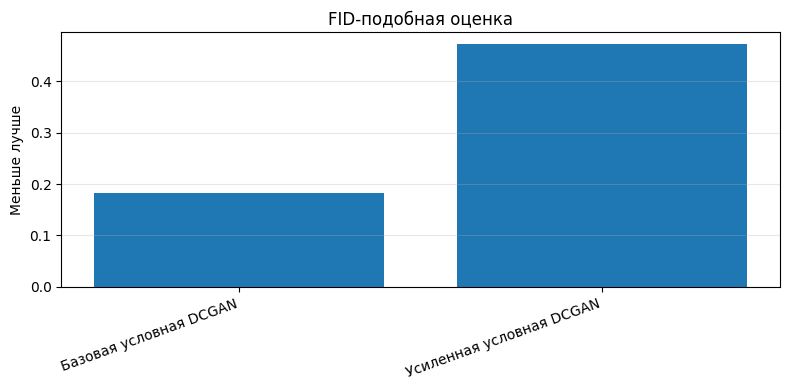

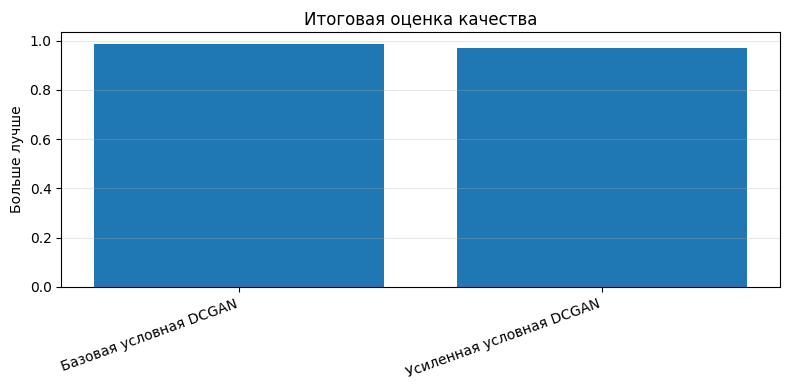

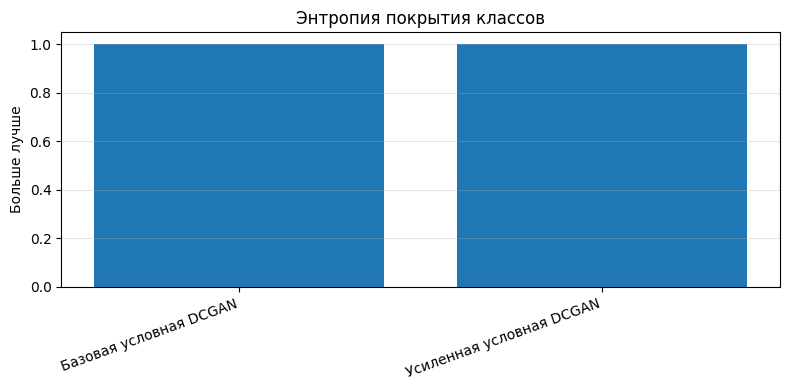

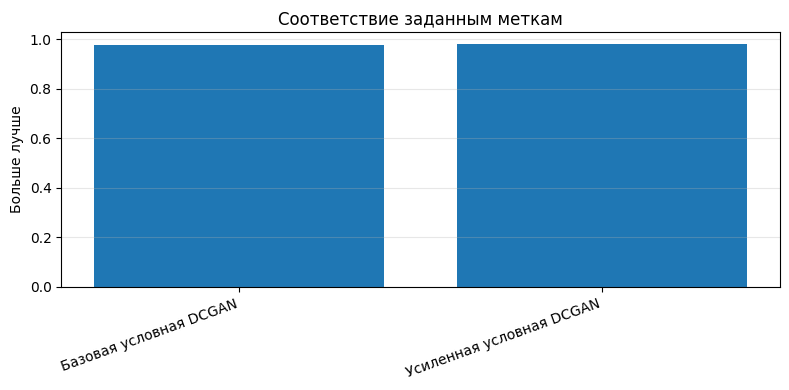

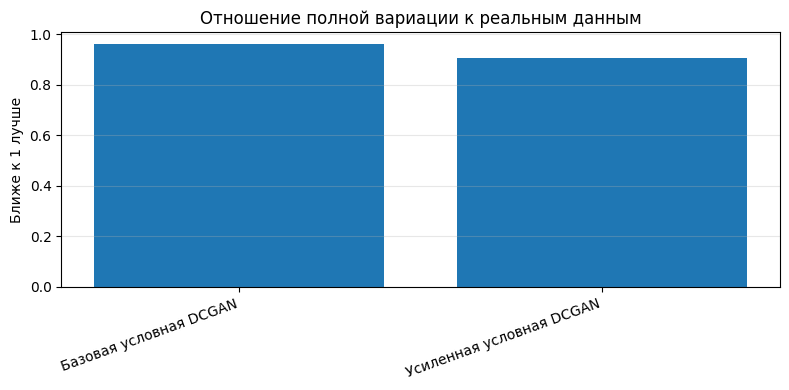

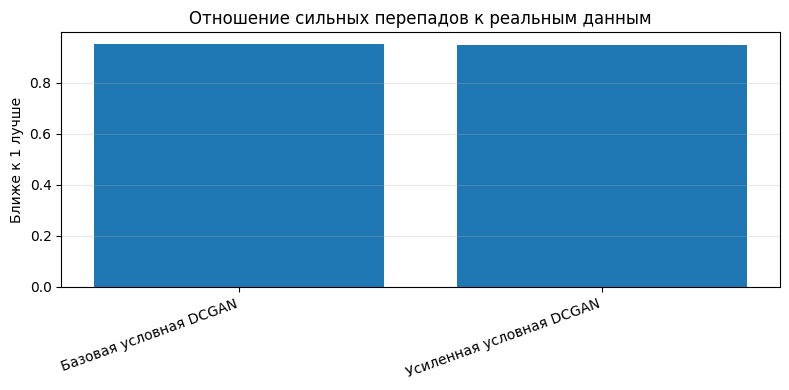

In [ ]:
def plot_final_bar(metric_name: str, title: str, ylabel: str) -> None:
    """Строит столбчатую диаграмму финальной метрики."""
    plt.figure(figsize=(8, 4))
    plt.bar(final_metrics["модель"], final_metrics[metric_name])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_final_bar("fid_like", "FID-подобная оценка", "Меньше лучше")
plot_final_bar("quality_score", "Итоговая оценка качества", "Больше лучше")
plot_final_bar("coverage_entropy", "Энтропия покрытия классов", "Больше лучше")
plot_final_bar("label_match_rate", "Соответствие заданным меткам", "Больше лучше")
plot_final_bar("tv_ratio", "Отношение полной вариации к реальным данным", "Ближе к 1 лучше")
plot_final_bar("high_contrast_ratio", "Отношение сильных перепадов к реальным данным", "Ближе к 1 лучше")


**График 1. FID-подобная оценка**

На графике сравнивается FID-подобная оценка двух генераторов. Для этой метрики меньшее значение считается лучшим, потому что оно означает меньшую дистанцию между распределением признаков реальных изображений и распределением признаков сгенерированных изображений.

Базовая условная DCGAN получила значение около 0.18, а усиленная условная DCGAN - около 0.47. Разница заметная: базовая модель почти в 2.5 раза лучше по этой метрике. Это означает, что изображения базовой модели в признаковом пространстве оценочного классификатора ближе к реальным изображениям Fashion MNIST.

Важно учитывать, что это не классический FID на Inception-сети, а адаптированная FID-подобная оценка для маленьких одноканальных изображений 28x28. Поэтому абсолютные значения не стоит сравнивать с FID из задач генерации цветных изображений высокого разрешения. В рамках данного эксперимента метрика корректна для относительного сравнения двух моделей.

Вывод: по близости к реальному распределению изображений уверенно выигрывает базовая условная DCGAN.

**График 2. Итоговая оценка качества**

Итоговая оценка качества объединяет несколько признаков генерации: близость к реальным изображениям, покрытие классов, соответствие заданным меткам, разнообразие и штрафы за визуальные артефакты. Для этой метрики большее значение считается лучшим.

Обе модели получили высокие значения: базовая условная DCGAN находится около 0.984, усиленная условная DCGAN - около 0.971. Это означает, что обе модели успешно обучились и дают пригодную генерацию. Однако базовая модель имеет небольшое, но устойчивое преимущество.

Разница между моделями не огромная, но она согласуется с FID-подобной оценкой. Базовая модель лучше попадает в распределение реальных изображений и поэтому получает более высокий общий балл.

Вывод: обе модели работают хорошо, но по совокупной оценке качества лучшей является базовая условная DCGAN.

**График 3. Энтропия покрытия классов**

Энтропия покрытия классов показывает, насколько равномерно генератор создает изображения всех 10 классов Fashion MNIST. Значение, близкое к 1.0, означает равномерное покрытие классов. Значение, близкое к 0, указывало бы на mode collapse, когда генератор создает только один или несколько классов.

Обе модели имеют значение почти 1.0. Это важный результат: ни базовая, ни усиленная модель не потеряли отдельные классы. Генераторы создают футболки, брюки, пуловеры, платья, пальто, сандалии, рубашки, кроссовки, сумки и ботинки.

Эта метрика особенно важна, потому что в предыдущих версиях эксперимента отдельные классы выпадали. В финальной версии проблема устранена. Условная архитектура и сбалансированная генерация меток обеспечивают равномерное покрытие всех классов.

Вывод: обе модели успешно избегают mode collapse по классам. По покрытию классов различия между моделями практически отсутствуют.

**График 4. Соответствие заданным меткам**

Метрика соответствия заданным меткам показывает, как часто сгенерированное изображение распознается оценочным классификатором как тот класс, который был передан генератору. Для этой метрики большее значение считается лучшим.

Обе модели получили значения около 0.98. Это означает, что условная генерация работает корректно. Если генератору задан класс сумка, он в большинстве случаев создает объект, который действительно выглядит как сумка. Если задан класс ботинок, он генерирует изображение, похожее на ботинок.

Усиленная условная DCGAN немного превосходит базовую модель по этой метрике. Однако разница очень мала и не перекрывает проигрыш усиленной модели по FID-подобной оценке и итоговой оценке качества.

Вывод: обе модели хорошо используют условные метки. Усиленная модель немного лучше следует заданному классу, но базовая модель в целом остается сильнее по качеству изображения.

**График 5. Отношение полной вариации к реальным данным**

Полная вариация измеряет среднюю интенсивность изменений между соседними пикселями. Эта метрика помогает обнаруживать две крайности: слишком гладкие изображения и слишком шумные изображения. Значение, близкое к 1.0, означает, что уровень локальной изменчивости похож на реальные данные.

У базовой условной DCGAN значение ближе к 1.0, примерно 0.96. У усиленной условной DCGAN значение ниже, примерно 0.90. Это говорит о том, что базовая модель лучше воспроизводит локальную структуру реальных изображений. Усиленная модель может создавать немного более сглаженные изображения или терять часть мелкой пиксельной структуры.

Эта метрика не является главным показателем качества, но хорошо дополняет визуальную проверку. Если бы значение было сильно выше 1.0, можно было бы подозревать шум и резкие артефакты. Если бы оно было сильно ниже 1.0, это указывало бы на чрезмерное сглаживание. Здесь оба значения находятся в допустимой зоне, но базовая модель ближе к реальным данным.

Вывод: по локальной пиксельной структуре базовая условная DCGAN лучше соответствует реальному Fashion MNIST.

**График 6. Отношение сильных перепадов к реальным данным**

Эта метрика показывает, насколько доля резких соседних пиксельных перепадов в сгенерированных изображениях похожа на долю таких перепадов в реальных изображениях. Значение, близкое к 1.0, считается лучшим.

Обе модели находятся близко к 1.0, примерно в диапазоне 0.94-0.95. Это означает, что генераторы не создают чрезмерно резкие, штрих-кодные или шумовые изображения. Одновременно они не становятся слишком размытыми: контуры объектов сохраняются.

Разница между моделями здесь минимальна. Метрика показывает, что обе архитектуры научились воспроизводить силуэты одежды без выраженных высокочастотных артефактов.

Вывод: обе модели имеют нормальный уровень резких перепадов. По этой метрике явного победителя нет.

**Общий вывод по финальным сравнительным графикам**

Финальные графики показывают, что обе модели успешно обучились: классы покрываются равномерно, соответствие заданным меткам высокое, а визуальные артефакты находятся в допустимом диапазоне.

При этом базовая условная DCGAN является более удачной моделью для данной задачи. Она выигрывает по двум самым важным интегральным критериям: FID-подобной оценке и итоговой оценке качества. Также она лучше соответствует реальному уровню полной вариации изображений.

Усиленная условная DCGAN немного лучше следует заданным меткам, но это преимущество слишком мало. С учетом более высокой вычислительной стоимости и более слабой FID-подобной оценки усиленная архитектура не дает практического выигрыша на Fashion MNIST.

Итоговый исследовательский вывод: для изображений Fashion MNIST размером 28x28 базовая условная DCGAN дает лучший баланс качества, устойчивости и вычислительной эффективности, чем более сложная усиленная условная DCGAN.


## 32. Проверка ближайших соседей

Этот блок сравнивает сгенерированные изображения с ближайшими реальными изображениями из обучающей выборки. Цель - проверить, не сводится ли генерация к простому копированию тренировочных примеров.

Для каждого класса выводится верхний ряд сгенерированных изображений и нижний ряд ближайших реальных соседей. Подписи вынесены за пределы изображений, чтобы не перекрывать содержимое. Расстояние `d` показывает близость в признаковом пространстве оценочного классификатора.

Для Fashion MNIST малые расстояния возможны даже без копирования, потому что изображения простые и имеют типовые силуэты. Поэтому анализ должен учитывать не только число `d`, но и визуальное сходство деталей.


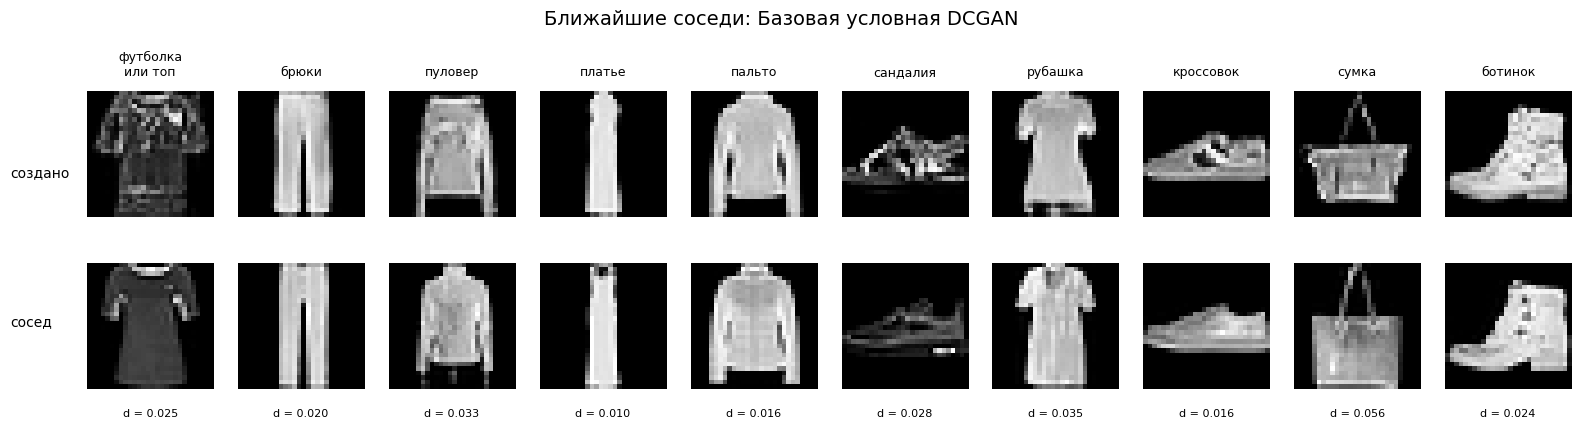

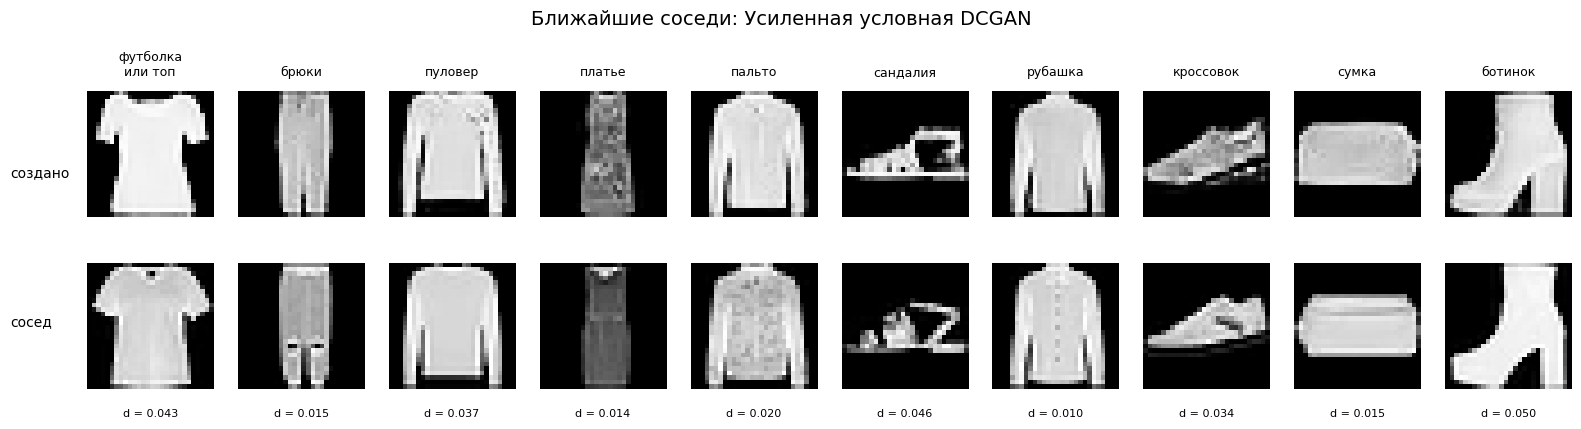

,модель,класс,индекс_ближайшего_соседа,расстояние
0,Базовая условная DCGAN,футболка или топ,1396,0.025440
1,Базовая условная DCGAN,брюки,1019,0.019951
2,Базовая условная DCGAN,пуловер,4948,0.032973
3,Базовая условная DCGAN,платье,4637,0.010134
4,Базовая условная DCGAN,пальто,1384,0.016020
5,Базовая условная DCGAN,сандалия,926,0.028011
6,Базовая условная DCGAN,рубашка,3001,0.034610
7,Базовая условная DCGAN,кроссовок,2641,0.016474
8,Базовая условная DCGAN,сумка,3621,0.055630
9,Базовая условная DCGAN,ботинок,431,0.023935


In [ ]:
def find_nearest_real_indices(
    generated_images_01: np.ndarray,
    real_images_01: np.ndarray,
    max_real_images: int = 5000,
) -> Tuple[np.ndarray, np.ndarray]:
    """Находит ближайшие реальные изображения для заданного набора созданных изображений."""
    # Ограничиваем количество реальных изображений, чтобы проверка оставалась быстрой в Colab.
    real_subset = real_images_01[:max_real_images]

    # Для поиска ближайшего соседа изображения переводятся в плоские векторы.
    generated_flat = generated_images_01.reshape(len(generated_images_01), -1).astype("float32")
    real_flat = real_subset.reshape(len(real_subset), -1).astype("float32")

    nearest_indices = []
    nearest_distances = []
    for generated_vector in generated_flat:
        # Среднеквадратичное расстояние хорошо подходит для грубой проверки на запоминание.
        distances = np.mean((real_flat - generated_vector[None, :]) ** 2, axis=1)
        nearest_index = int(np.argmin(distances))
        nearest_indices.append(nearest_index)
        nearest_distances.append(float(distances[nearest_index]))

    return np.array(nearest_indices, dtype="int32"), np.array(nearest_distances, dtype="float32")


def short_class_label(class_name: str) -> str:
    """Возвращает компактную подпись класса для узкой ячейки графика."""
    replacements = {
        "футболка или топ": "футболка\nили топ",
    }
    return replacements.get(class_name, class_name)


def show_nearest_neighbors(
    trainer: ConditionalGanTrainer,
    config: ExperimentConfig,
    samples_per_model: Optional[int] = None,
    save_path: Optional[Path] = None,
) -> pd.DataFrame:
    """Показывает созданные изображения и их ближайшие реальные изображения без наложения подписей."""
    # По умолчанию берем по одному примеру на каждый класс, чтобы сетка была читаемой.
    samples_per_model = samples_per_model or config.num_classes
    if samples_per_model == config.num_classes:
        labels = np.arange(config.num_classes, dtype="int32")
    else:
        labels = build_balanced_labels(samples_per_model, config.num_classes)

    # Генерируем один фиксированный набор изображений для визуальной проверки.
    noise = tf.random.normal([samples_per_model, config.latent_dim], seed=config.seed + 101)
    generated_images = trainer.ema_generator([noise, tf.convert_to_tensor(labels)], training=False).numpy()
    generated_images_01 = gan_to_classifier_range(generated_images)

    nearest_indices, distances = find_nearest_real_indices(
        generated_images_01,
        train_images_classifier,
        max_real_images=5000,
    )

    # Подписи рисуются как отдельные текстовые элементы, а не как заголовки осей.
    # Поэтому они не перекрывают изображения даже при длинных русских названиях классов.
    fig, axes = plt.subplots(
        2,
        samples_per_model,
        figsize=(max(13, samples_per_model * 1.6), 4.8),
    )
    fig.subplots_adjust(left=0.065, right=0.995, top=0.78, bottom=0.16, wspace=0.16, hspace=0.36)
    fig.suptitle(f"Ближайшие соседи: {trainer.spec.title}", fontsize=14, y=0.95)
    fig.text(0.018, 0.61, "создано", va="center", ha="left", fontsize=10)
    fig.text(0.018, 0.30, "сосед", va="center", ha="left", fontsize=10)

    for col in range(samples_per_model):
        generated_axis = axes[0, col]
        nearest_axis = axes[1, col]

        generated_axis.imshow(generated_images_01[col, :, :, 0], cmap="gray", vmin=0, vmax=1)
        generated_axis.axis("off")
        generated_axis.text(
            0.5,
            1.10,
            short_class_label(str(CLASS_NAMES[labels[col]])),
            transform=generated_axis.transAxes,
            ha="center",
            va="bottom",
            fontsize=9,
        )

        nearest_axis.imshow(train_images_classifier[nearest_indices[col], :, :, 0], cmap="gray", vmin=0, vmax=1)
        nearest_axis.axis("off")
        nearest_axis.text(
            0.5,
            -0.16,
            f"d = {distances[col]:.3f}",
            transform=nearest_axis.transAxes,
            ha="center",
            va="top",
            fontsize=8,
        )

    if save_path is not None:
        fig.savefig(save_path, dpi=170, bbox_inches="tight", pad_inches=0.25)
    plt.show()

    # Таблица помогает проверить расстояния численно и не перегружает сам рисунок подписями.
    summary = pd.DataFrame(
        {
            "модель": trainer.spec.title,
            "класс": CLASS_NAMES[labels],
            "индекс_ближайшего_соседа": nearest_indices,
            "расстояние": distances,
        }
    )
    return summary


nearest_neighbor_tables = []
for key, trainer in trainers_by_key.items():
    nearest_neighbor_tables.append(
        show_nearest_neighbors(
            trainer,
            CONFIG,
            samples_per_model=CONFIG.num_classes,
            save_path=IMAGE_DIR / f"{key}_nearest_neighbors.png",
        )
    )

nearest_neighbors_table = pd.concat(nearest_neighbor_tables, ignore_index=True)
nearest_neighbors_table.to_csv(TABLE_DIR / "nearest_neighbors.csv", index=False)
display(nearest_neighbors_table)


Вывод ближайших соседей читается корректно. Подписи классов не перекрывают изображения, а расстояния вынесены под нижний ряд. Это делает визуальную проверку пригодной для отчета.

Ближайшие реальные соседи похожи на сгенерированные изображения по классу и общему силуэту. Это ожидаемо. Fashion MNIST содержит много типовых объектов, поэтому хорошая генерация будет иметь близких соседей в обучающей выборке.

Признаков прямого копирования не видно. Сгенерированные изображения похожи на реальные по структуре, но не выглядят дословными дубликатами. Малые расстояния допустимы для изображений 28 x 28, особенно у простых классов вроде брюк или обуви.


## 33. Автоматический итог исследования

Этот блок формирует текстовый итог по финальным метрикам. Он выбирает лучшую модель по нескольким критериям и проверяет риски: пропущенные классы, слабое покрытие, плохое соответствие меткам и чрезмерные пиксельные артефакты.

Автоматический итог помогает зафиксировать результат запуска, но окончательное исследовательское заключение должно учитывать также графики обучения, визуальные сетки, таблицу по классам и ближайших соседей.

Если автоматический итог не содержит предупреждений, это означает, что модель прошла основные численные проверки, но визуальная оценка все равно остается обязательной частью анализа GAN.


In [ ]:
def format_model_metric(frame: pd.DataFrame, metric: str, better: str) -> str:
    """Возвращает строку с лучшей моделью по метрике."""
    if better == "min":
        row = frame.loc[frame[metric].idxmin()]
    else:
        row = frame.loc[frame[metric].idxmax()]
    return f"{row['модель']} ({metric} = {row[metric]:.4f})"


def print_final_conclusion(metrics_frame: pd.DataFrame) -> None:
    """Печатает краткий итог сравнения моделей."""
    print("Итоговое сравнение")
    print("-" * 80)
    print("Лучшая модель по FID-подобной оценке:", format_model_metric(metrics_frame, "fid_like", "min"))
    print("Лучшая модель по итоговой оценке качества:", format_model_metric(metrics_frame, "quality_score", "max"))
    print("Лучшая модель по соответствию меткам:", format_model_metric(metrics_frame, "label_match_rate", "max"))
    print("Лучшая модель по покрытию классов:", format_model_metric(metrics_frame, "coverage_entropy", "max"))

    print("\nПроверка рисков")
    for _, row in metrics_frame.iterrows():
        warnings_list = []
        if row["missing_class_count"] > 0:
            warnings_list.append(f"пропущено классов: {int(row['missing_class_count'])}")
        if row["label_match_rate"] < 0.70:
            warnings_list.append("слабое соответствие заданным меткам")
        if row["fid_like"] > 15:
            warnings_list.append("высокая FID-подобная оценка")
        if row["tv_ratio"] > 1.8 or row["high_contrast_ratio"] > 2.0:
            warnings_list.append("возможны шумовые или штрих-кодные артефакты")

        status = "существенных предупреждений нет" if not warnings_list else "; ".join(warnings_list)
        print(f"{row['модель']}: {status}")


print_final_conclusion(final_metrics)


Итоговое сравнение
--------------------------------------------------------------------------------
Лучшая модель по FID-подобной оценке: Базовая условная DCGAN (fid_like = 0.1831)
Лучшая модель по итоговой оценке качества: Базовая условная DCGAN (quality_score = 0.9840)
Лучшая модель по соответствию меткам: Усиленная условная DCGAN (label_match_rate = 0.9783)
Лучшая модель по покрытию классов: Усиленная условная DCGAN (coverage_entropy = 0.9999)

Проверка рисков
Базовая условная DCGAN: существенных предупреждений нет
Усиленная условная DCGAN: существенных предупреждений нет


Автоматический итог подтверждает основное заключение: лучшая модель по FID-подобной оценке и итоговому качеству - **Базовая условная DCGAN**. Усиленная модель немного лучше по соответствию меткам и покрытию классов, но различия там очень малы.

Блок проверки рисков не обнаружил существенных предупреждений. Это согласуется с финальными таблицами: пропущенных классов нет, покрытие почти равномерное, пиксельные артефакты находятся в допустимом диапазоне.

Итог нужно читать вместе с визуальными сетками. В данном запуске численные и визуальные выводы согласованы, поэтому результат можно считать устойчивым.


## 34. Расширенный исследовательский анализ выполненного запуска

Контрольный запуск на NVIDIA L4 показал устойчивое и качественное обучение обеих условных DCGAN. Эксперимент важен тем, что он прошел несколько уровней проверки: предварительный разведочный анализ данных, обучение независимого оценочного классификатора, проверку одного шага GAN, длинное обучение двух моделей, финальную численную оценку, визуальную проверку, интерполяцию скрытого пространства и анализ ближайших соседей.

### Данные и исходные предпосылки

Fashion MNIST оказался подходящим набором для сравнения двух генераторов. Классы сбалансированы, изображения выровнены по центру, фон почти черный, а различия между категориями в основном задаются силуэтом. Это делает задачу достаточно простой для DCGAN, но не тривиальной: классы верхней одежды визуально пересекаются, поэтому модель должна не просто рисовать контуры, а учитывать условную метку.

Разведочный анализ показал, что отсутствие класса в генерации нельзя объяснить дисбалансом исходных данных. Все классы представлены равномерно, поэтому качество по категориям зависит от архитектуры и обучения GAN.

### Оценочный классификатор

Классификатор достиг проверочной точности 0.9321. Этого достаточно для использования модели как внешнего оценщика признаков и классов. При этом классификатор не участвует в обучении генератора, что снижает риск появления искусственных паттернов, специально оптимизированных под классификатор.

Его роль в исследовании - измерительная. Он помогает оценить, насколько сгенерированные изображения похожи на реальные классы Fashion MNIST и насколько равномерно покрыты категории.

### Проверка одного шага обучения

Проверка одного шага показала положительное изменение весов у генератора и дискриминатора для обеих моделей. Это важный контроль качества кода. Он подтверждает, что пользовательский цикл обучения действительно обновляет параметры и что `GradientTape`, mixed precision и оптимизаторы работают согласованно.

Без такой проверки можно было бы получить длинный лог обучения, в котором функции потерь печатаются, но веса фактически не меняются. В этом запуске такой проблемы нет.

### Динамика обучения

Базовая условная DCGAN обучалась быстрее и дала резкое улучшение уже в первые 20-30 эпох. FID-подобная оценка снизилась с очень высокого стартового значения до уровня ниже 2 к 20-й эпохе, а затем продолжила улучшаться медленнее. Это типичная динамика успешной GAN: сначала модель быстро осваивает грубую структуру, затем постепенно уточняет распределение.

Усиленная условная DCGAN обучалась медленнее: средняя эпоха занимала около 31 секунды против 18.4 секунды у базовой модели. Это ожидаемо, потому что усиленный генератор содержит больше параметров и более тяжелые сверточные блоки. Несмотря на это, существенного прироста качества он не дал.

Графики функций потерь генератора и дискриминатора имеют колебания. Это нормально для состязательного обучения. Важнее, что качество растет, FID-подобная оценка падает, покрытие классов становится почти полным, а градиенты остаются существующими и конечными почти на всех шагах.

### Финальные метрики

Финальная оценка показывает преимущество базовой модели по двум главным агрегированным критериям: FID-подобная оценка 0.1831 и итоговый показатель качества 0.9840. Усиленная модель получила FID-подобную оценку 0.4714 и итоговый показатель 0.9709.

Обе модели покрывают все классы. Минимальная доля класса находится около 0.095, что близко к идеальному равномерному значению 0.10. Пропущенных классов нет. Это означает, что условная схема с проекционным дискриминатором решила проблему выпадения категорий без специальной подгонки под отдельный класс.

### Визуальная оценка

Визуальные сетки подтверждают таблицы: модели создают узнаваемые объекты одежды и обуви. Самые уверенные классы - брюки, обувь и сумка. Наиболее сложная категория - рубашка, что согласуется с метриками по классам и с визуальной похожестью рубашки на другие виды верхней одежды.

У базовой модели визуальное качество достаточно высокое для Fashion MNIST. Усиленная модель также генерирует корректные изображения, но не демонстрирует очевидного преимущества, которое оправдало бы большую вычислительную стоимость.

### Интерполяция и ближайшие соседи

Интерполяции в скрытом пространстве показывают плавные изменения изображений. Это говорит о том, что генератор изучил непрерывное распределение, а не только набор отдельных шаблонов.

Проверка ближайших соседей не выявила признаков простого копирования обучающих изображений. Соседи похожи по силуэту и классу, но сгенерированные изображения не выглядят дословными дубликатами. Для Fashion MNIST малые расстояния в признаковом пространстве допустимы, потому что изображения простые и типовые.

### Итоговое исследовательское заключение

В данном эксперименте усложнение генератора не улучшило качество. Базовая условная DCGAN дала лучший баланс качества, скорости и устойчивости. Усиленная условная DCGAN корректно обучилась и покрыла все классы, но оказалась медленнее и уступила по FID-подобной оценке и итоговому качеству.

Главный практический вывод: для Fashion MNIST с изображениями 28 x 28 компактная условная DCGAN с проекционным дискриминатором, hinge loss и EMA-генератором является достаточной и более эффективной архитектурой.


## 35. Сохранение результатов

Финальный блок сохраняет артефакты эксперимента: таблицы метрик, историю обучения, веса лучших моделей, изображения и текстовый итог.

Сохранение нужно для воспроизводимости и последующего анализа. Таблицы можно использовать в отчете, изображения - для визуального сравнения, а веса - для повторной генерации без нового обучения.

Каталог артефактов печатается в выводе ячейки. В Colab эти файлы можно скачать или сохранить на Google Drive при необходимости.


In [ ]:
def save_experiment_artifacts(
    trainers: Dict[str, ConditionalGanTrainer],
    final_metrics_frame: pd.DataFrame,
    per_class_frame: pd.DataFrame,
    config: ExperimentConfig,
) -> None:
    """Сохраняет ключевые артефакты проекта."""
    with open(PROJECT_DIR / "config.json", "w", encoding="utf-8") as file:
        json.dump(asdict(config), file, ensure_ascii=False, indent=2)

    final_metrics_frame.to_csv(TABLE_DIR / "final_metrics.csv", index=False)
    per_class_frame.to_csv(TABLE_DIR / "per_class_metrics.csv", index=False)
    stability_table.to_csv(TABLE_DIR / "training_stability.csv", index=False)

    for key, trainer in trainers.items():
        trainer.generator.save_weights(MODEL_DIR / f"{key}_generator_final.weights.h5")
        trainer.ema_generator.save_weights(MODEL_DIR / f"{key}_ema_generator_final.weights.h5")
        trainer.discriminator.save_weights(MODEL_DIR / f"{key}_discriminator_final.weights.h5")

    print(f"Артефакты сохранены в: {PROJECT_DIR}")


save_experiment_artifacts(trainers_by_key, final_metrics, per_class_metrics, CONFIG)


Артефакты сохранены в: /content/dcgan_fashion_mnist_final
